# Regression V2 — Final Project Reporting

Authorization: regression_v2_prompt5c_final_reporting.

This notebook is artifact-only. It performs no model fitting, prediction generation, SHAP calculation, bootstrap resampling, or original IID access.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
FINAL = ROOT / "outputs" / "final"
TABLES = FINAL / "tables"
FIGURES = FINAL / "figures"
REPORTS = ROOT / "outputs" / "reports"

def show_table(name, rows=None):
    frame = pd.read_csv(TABLES / name)
    display(frame if rows is None else frame.head(rows))

def show_image(name):
    display(Image(filename=str(FIGURES / name)))

display(Markdown("Artifact-only notebook setup complete. All displayed values and images are saved reporting artifacts."))

Artifact-only notebook setup complete. All displayed values and images are saved reporting artifacts.

## 1. Executive Summary

The frozen Stage 3 Primary produced a small observed overall IID MAE improvement over the frozen Global ensemble. It passed five of six predeclared conditions. C2 failed, so the required 3% Top-decile MAE improvement was not achieved.

,Model,Model ID,MAE,RMSE,R²,RMSLE,Median AE,P90 AE,MAPE %,WAPE %,Bottom-90 MAE,Top-decile MAE,Top-5% MAE,P85-P95 MAE,Top-decile signed error,Top-decile underprediction rate
0,Final Primary — Stage 3 500k,final_primary_stage3_500k,62.260626,134.920181,0.676640,0.387157,36.812194,133.121315,33.560168,24.949717,47.842469,191.966385,273.041013,98.839109,-129.973885,0.775956
1,Final Global — 500k,final_global_500k,62.444349,137.397192,0.664658,0.387272,36.850210,133.201254,33.529924,25.023341,47.744671,194.682683,280.589503,97.377178,-142.355856,0.792350


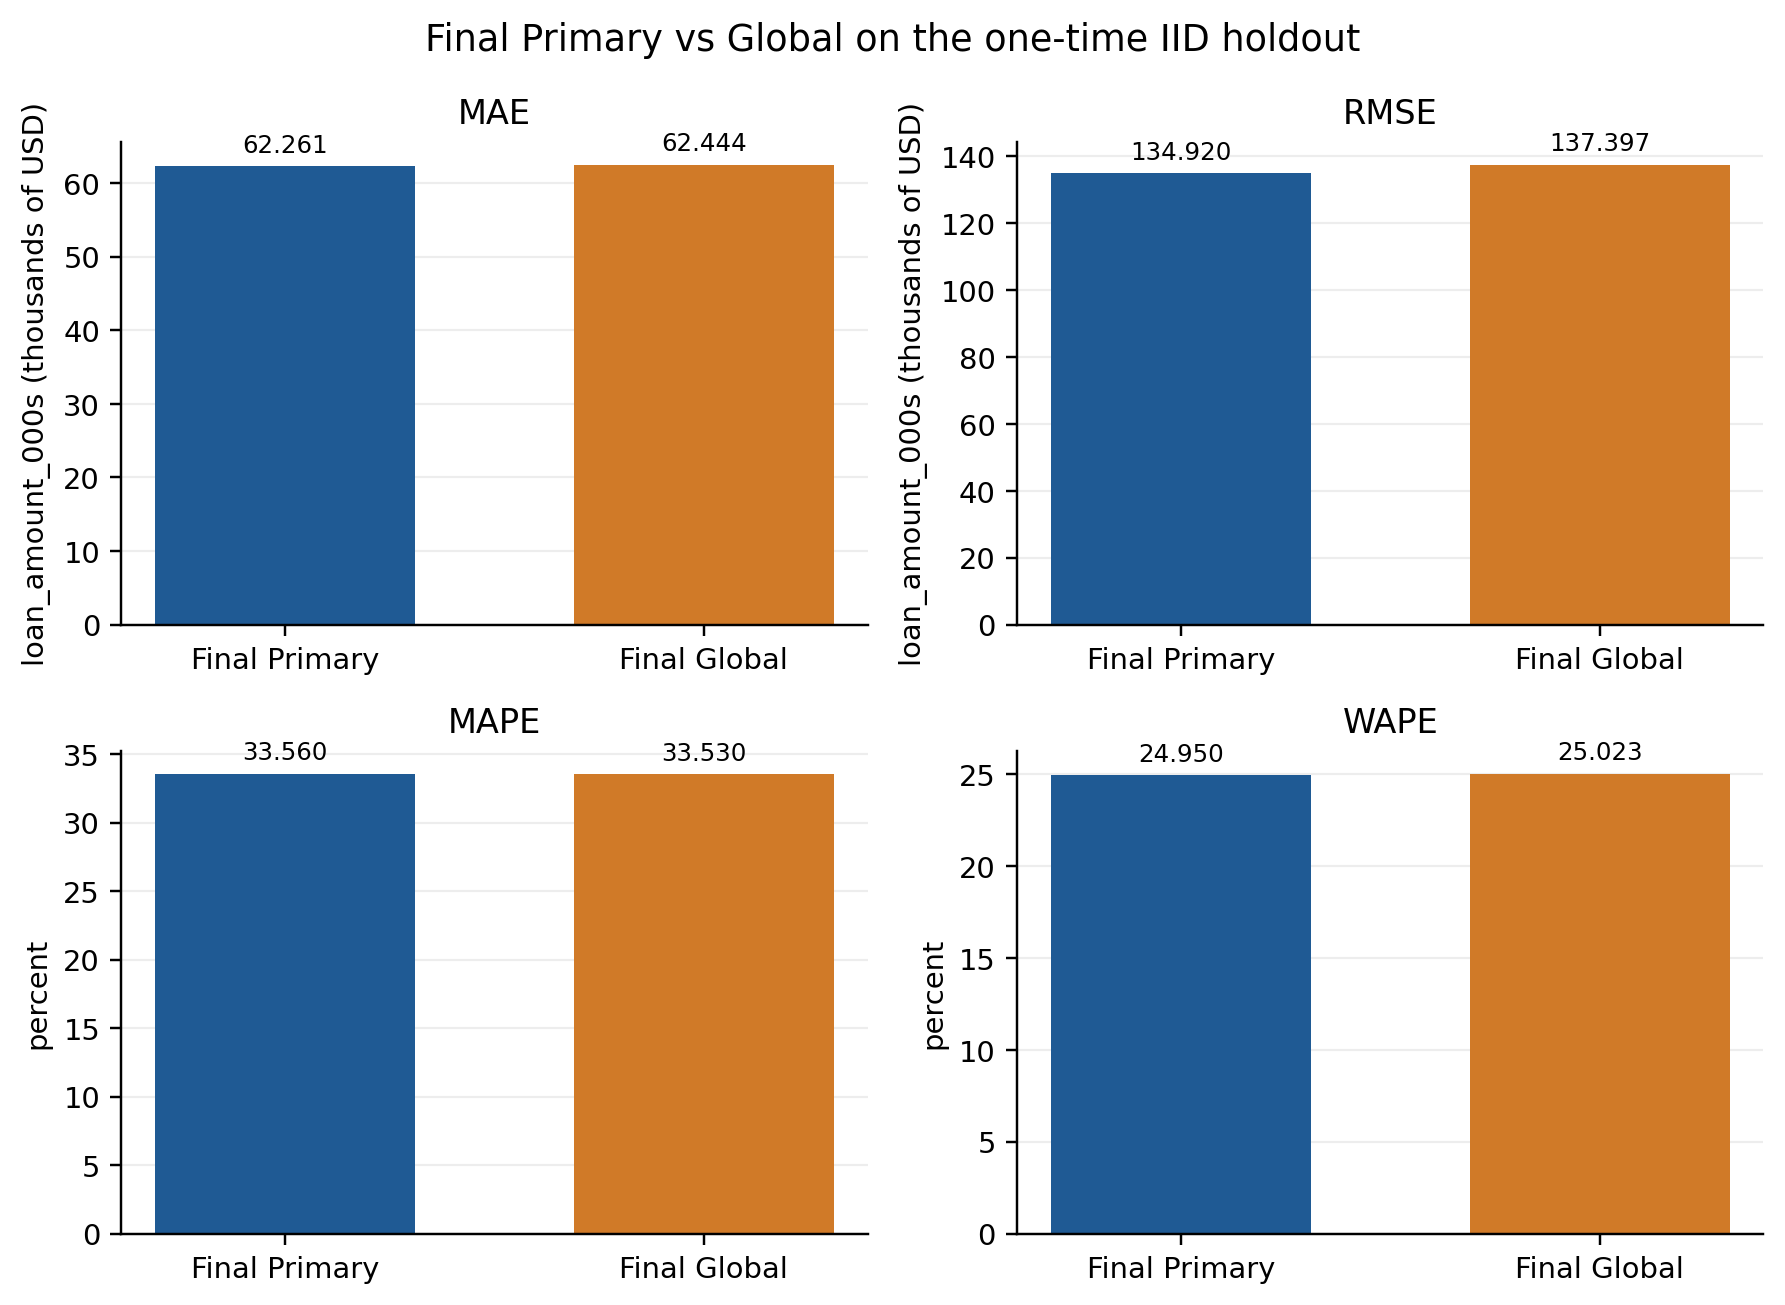

In [2]:
show_table('table_final_model_performance.csv')
show_image('figure01_iid_overall_metrics.png')

## 2. Data Lineage

The saved handoff validates the immutable Prompt 4C, 5A, and 5B evidence. Development contained 500,000 rows. The one-time IID holdout contained 75,000 rows and is closed.

In [3]:
handoff = json.loads((REPORTS / 'prompt5c_handoff_validation.json').read_text(encoding='utf-8'))
display(pd.DataFrame(handoff['checks'])[['artifact', 'actual_status', 'sha256', 'status']])

,artifact,actual_status,sha256,status
0,outputs/reports/PROMPT5B_READY.json,PASS_FINAL_FAIRNESS_AND_EXPLAINABILITY,843500bd9f0d7c2a9087ecb50ac6eaf6c15e6c681d8a1c...,PASS
1,outputs/reports/FINAL_FAIRNESS_EXPLAINABILITY....,PASS_FINAL_FAIRNESS_AND_EXPLAINABILITY,2025ec95cc564238e72fbb82ac33670c0272f166cf93d4...,PASS
2,outputs/reports/PROMPT5A_READY.json,PASS_FINAL_IID_EVALUATION_AND_ERROR_ANALYSIS,85c77589b0e43becd79c877c37aeed683441f836f463c3...,PASS
3,outputs/reports/FINAL_IID_EVALUATION.json,PASS_FINAL_IID_EVALUATION_AND_ERROR_ANALYSIS,87f401d1863d935d336bf21218f083cc802744ec25099e...,PASS
4,outputs/reports/PROMPT4C_READY.json,PASS_FINAL_PRE_IID_FREEZE,af50e8a222ec513ff60cad6be60bac48f3dc58de9e8d31...,PASS
5,outputs/reports/FINAL_PRE_IID_FREEZE.json,PASS_FINAL_PRE_IID_FREEZE,8f2b8e4fda80056770b916b7859ad0f6f89f2948236320...,PASS


## 3. Modeling Timeline

The research timeline covered baselines, boosting, lender diagnostics, deep tabular models, ensembles, Tail Gates, Meta-Gates, Residual Specialists, benefit-aware correction, Beat-probability shrinkage, and literature-based imbalance methods. Development research closed before final refit and IID access.

## 4. Final Architecture

The Global ensemble uses 0.60 CatBoost, 0.20 LightGBM, and 0.20 XGBoost. The Meta-Gate controls a frozen residual correction from the Residual Specialist.

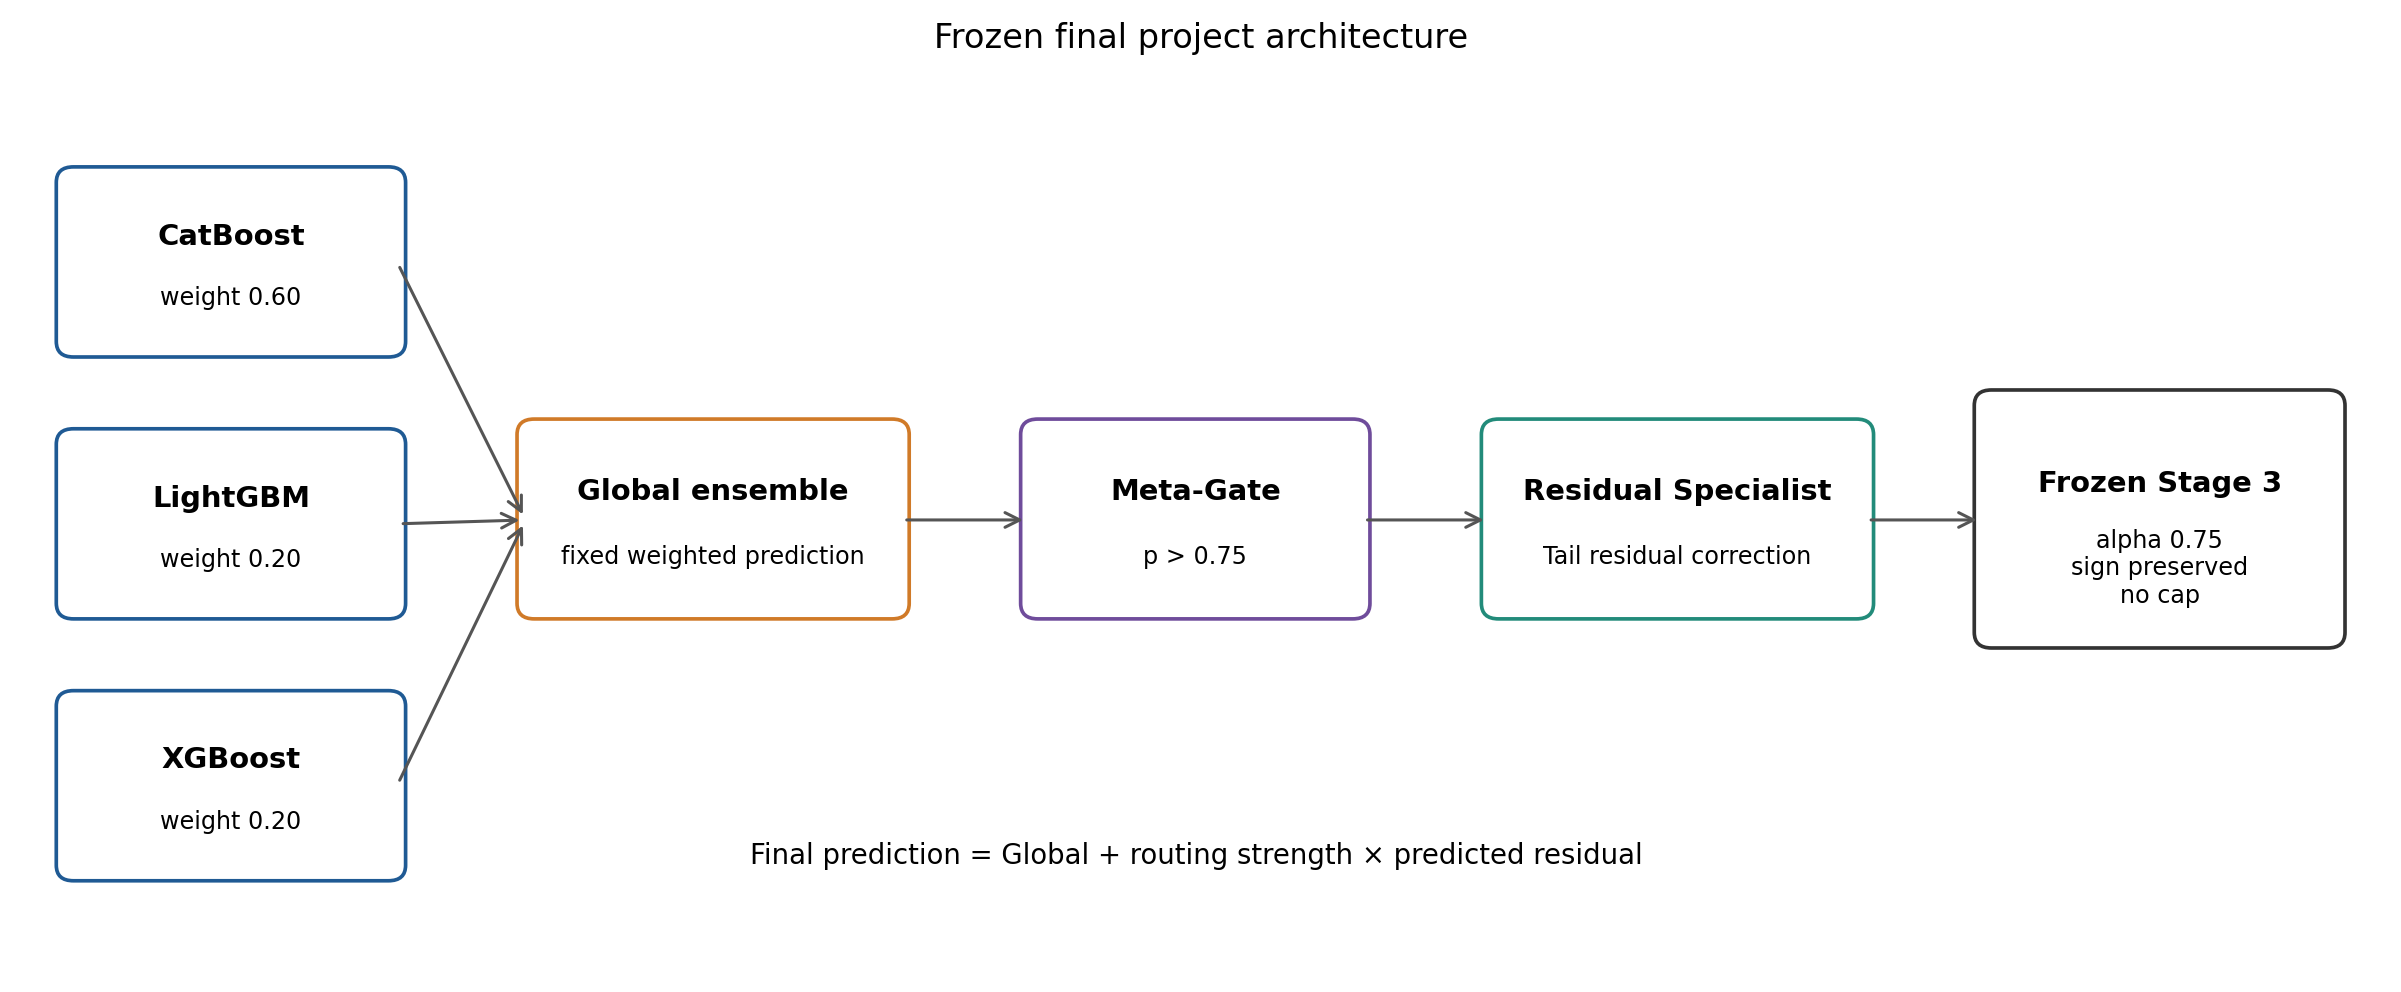

,Measure,Value,Frozen source
0,IID rows,75000.000000,outputs/reports/prompt5a_routing_diagnostics.csv
1,Routed rows,3583.000000,outputs/reports/prompt5a_routing_diagnostics.csv
2,Routing rate,0.047773,outputs/reports/prompt5a_routing_diagnostics.csv
3,Mean routed correction,27.773618,Frozen aggregate ratio from prompt5a_routing_d...
4,Median absolute routed correction,16.551000,Prompt 5C authorization Section 7; frozen Prom...
5,Positive correction rate,0.043693,outputs/reports/prompt5b_correction_behavior.csv
6,Negative correction rate,0.004080,outputs/reports/prompt5b_correction_behavior.csv
7,Zero correction rate,0.952227,outputs/reports/prompt5b_correction_behavior.csv
8,Routed-row realized benefit,3.845729,outputs/reports/prompt5a_routing_diagnostics.csv


In [4]:
show_image('figure15_project_architecture.png')
show_table('table_stage3_mechanism.csv')

## 5. Development Evidence

In [5]:
show_table('table_development_to_iid_transport.csv')

,Model ID,Development evidence,IID evidence,Development MAE,IID MAE,Development MAPE %,IID MAPE %,Development WAPE %,IID WAPE %,Development Bottom90 MAE,IID Bottom90 MAE,Development Top-decile MAE,IID Top-decile MAE,Development Top-decile underprediction,IID Top-decile underprediction
0,final_primary_stage3_500k,adaptive Development,untouched one-time holdout,62.196656,62.260626,34.338458,33.560168,24.995015,24.949717,47.669010,47.842469,192.756864,191.966385,0.777290,0.775956
1,final_global_500k,adaptive Development,untouched one-time holdout,62.356316,62.444349,34.305027,33.529924,25.059178,25.023341,47.576966,47.744671,195.178575,194.682683,0.793968,0.792350


## 6. Final Selection

Stage 3 was frozen before IID under a balanced conservative Tail-aware philosophy. IID did not trigger reselection.

In [6]:
show_table('table_six_condition_generalization.csv')

,Condition,Definition,Global IID value,Primary IID value,Threshold,PASS/FAIL
0,C1,Primary overall MAE improves over Global,62.444349,62.260626,62.444349,PASS
1,C2,Primary Top-decile MAE improves by at least 3%,194.682683,191.966385,188.842202,FAIL
2,C3,Primary Bottom-90 MAE worsens by no more than ...,47.744671,47.842469,47.864032,PASS
3,C4,Primary RMSE worsens by no more than 0.25%,137.397192,134.920181,137.740685,PASS
4,C5,Primary Top-decile signed error is closer to zero,-142.355856,-129.973885,142.355856,PASS
5,C6,Primary Top-decile underprediction rate decreases,0.792350,0.775956,0.792350,PASS


## 7. IID Evaluation

,Metric,Observed Primary minus Global,Paired bootstrap mean difference,Paired bootstrap median difference,95% CI lower,95% CI upper,Fraction resamples favoring Primary,Resamples,Seed
0,MAE,-0.183723,-0.183492,-0.184574,-0.262989,-0.104811,1.0,500,42
1,RMSE,-2.477011,-2.454021,-2.432419,-3.514729,-1.542489,1.0,500,42
2,MAPE,0.030244,0.030365,0.030260,0.022524,0.038501,0.0,500,42
3,WAPE,-0.073623,-0.073511,-0.073983,-0.104840,-0.041947,1.0,500,42
4,Bottom-90 MAE,0.097799,0.098034,0.097687,0.081441,0.114905,0.0,500,42
5,Top-decile MAE,-2.716298,-2.715244,-2.720549,-3.472434,-1.939967,1.0,500,42
6,Top-5% MAE,-7.548490,-7.550688,-7.566098,-9.028809,-6.139156,1.0,500,42


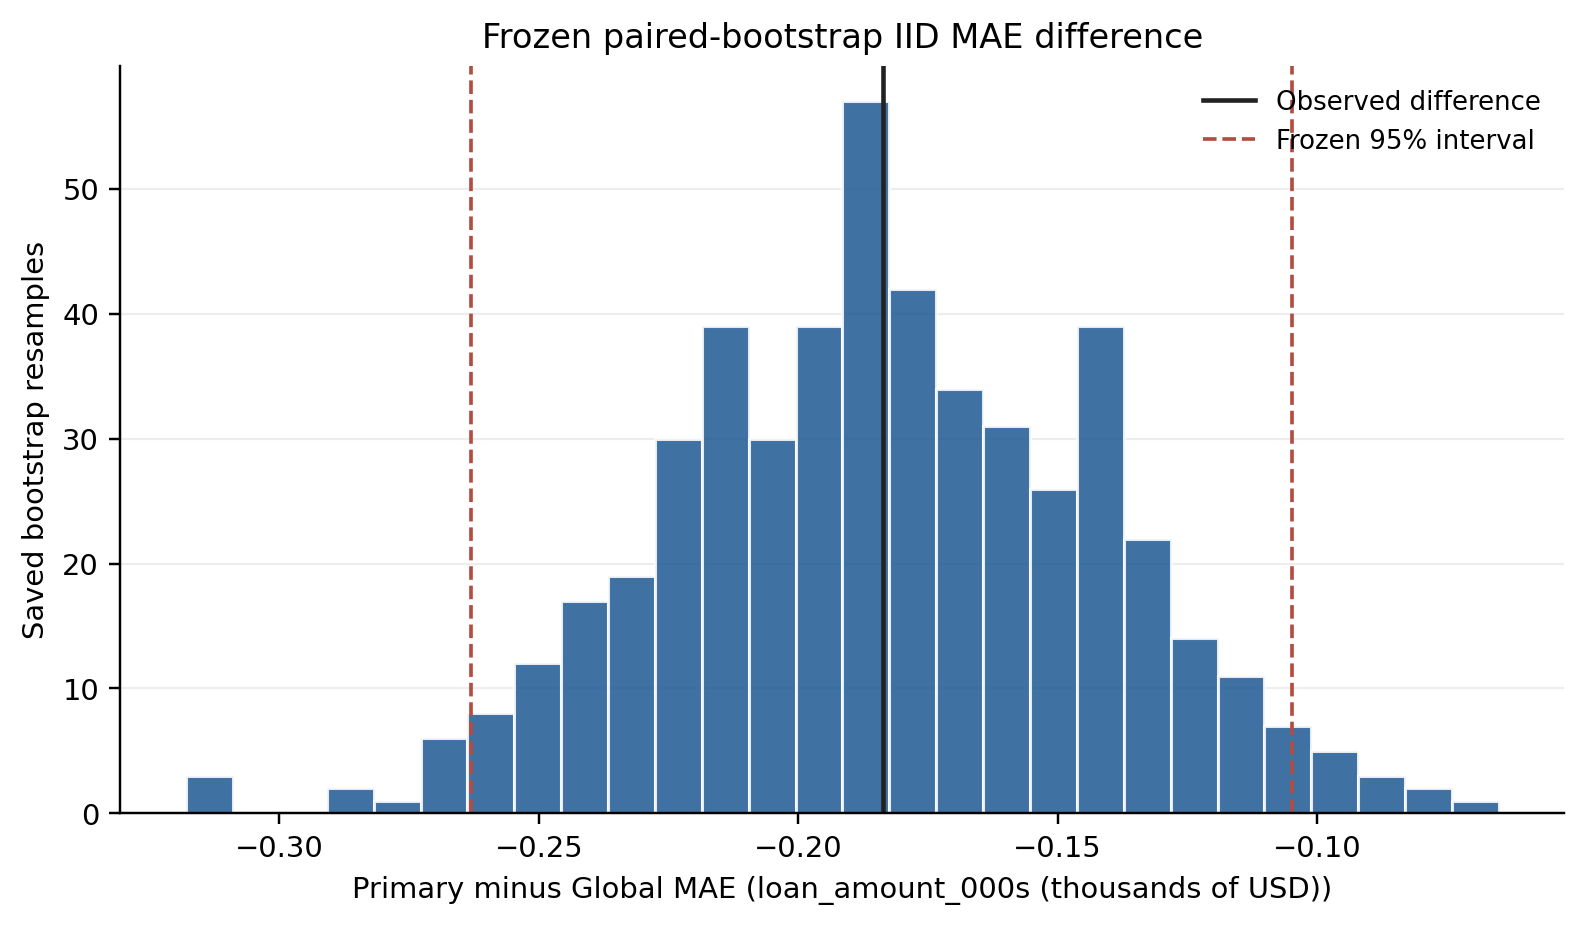

In [7]:
show_table('table_iid_primary_vs_global.csv')
show_image('figure07_iid_bootstrap_mae_difference.png')

## 8. Percentage Error

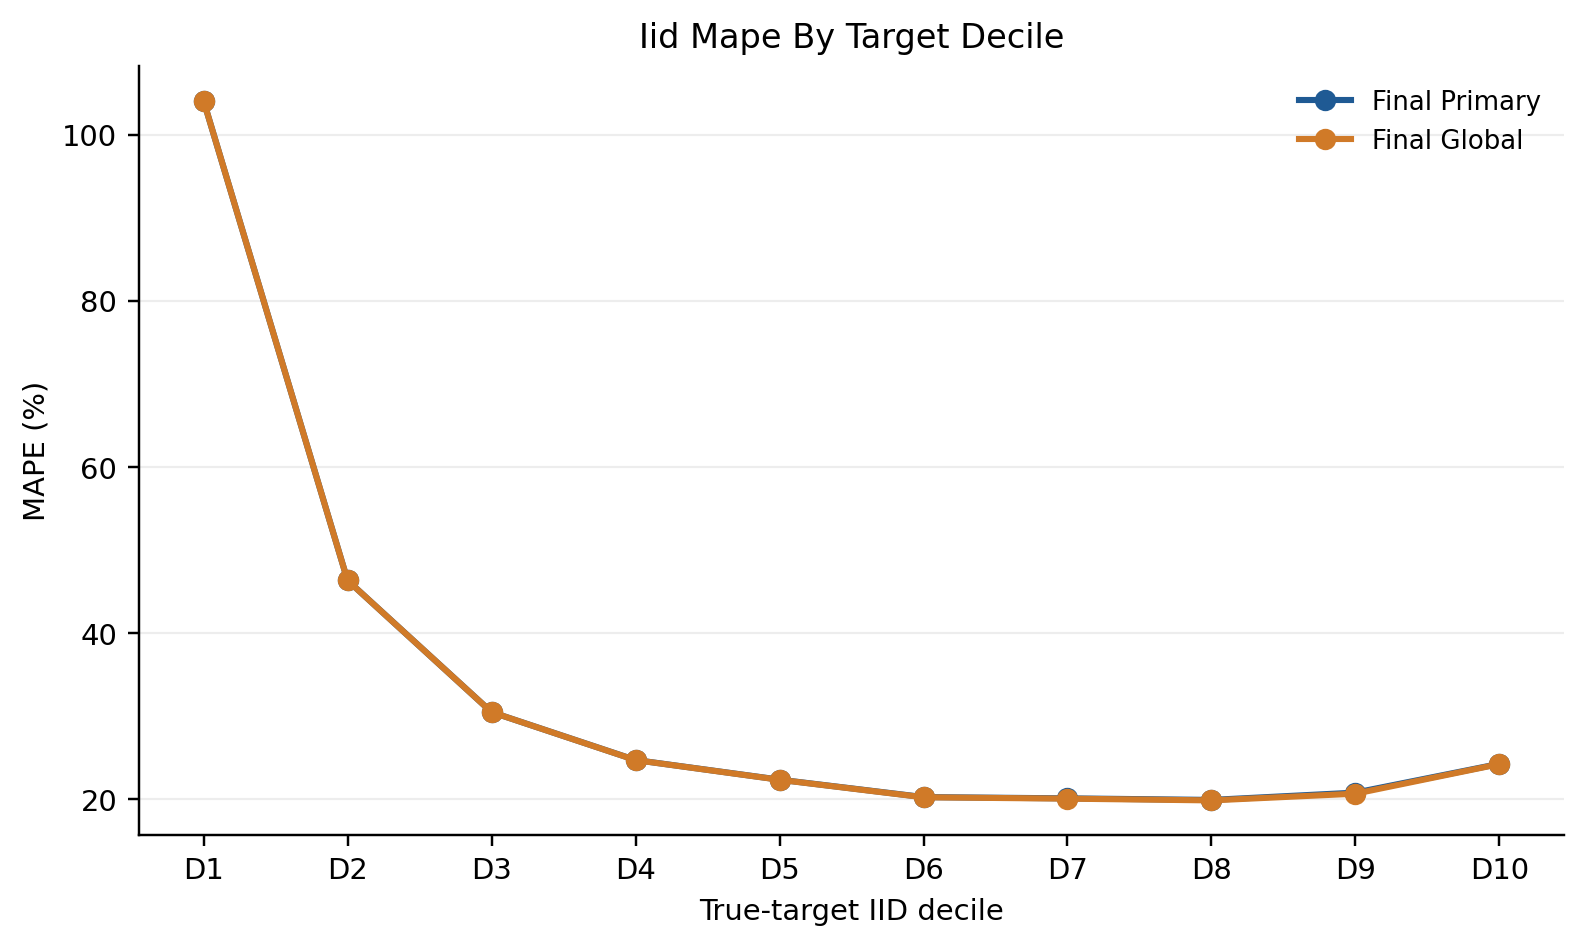

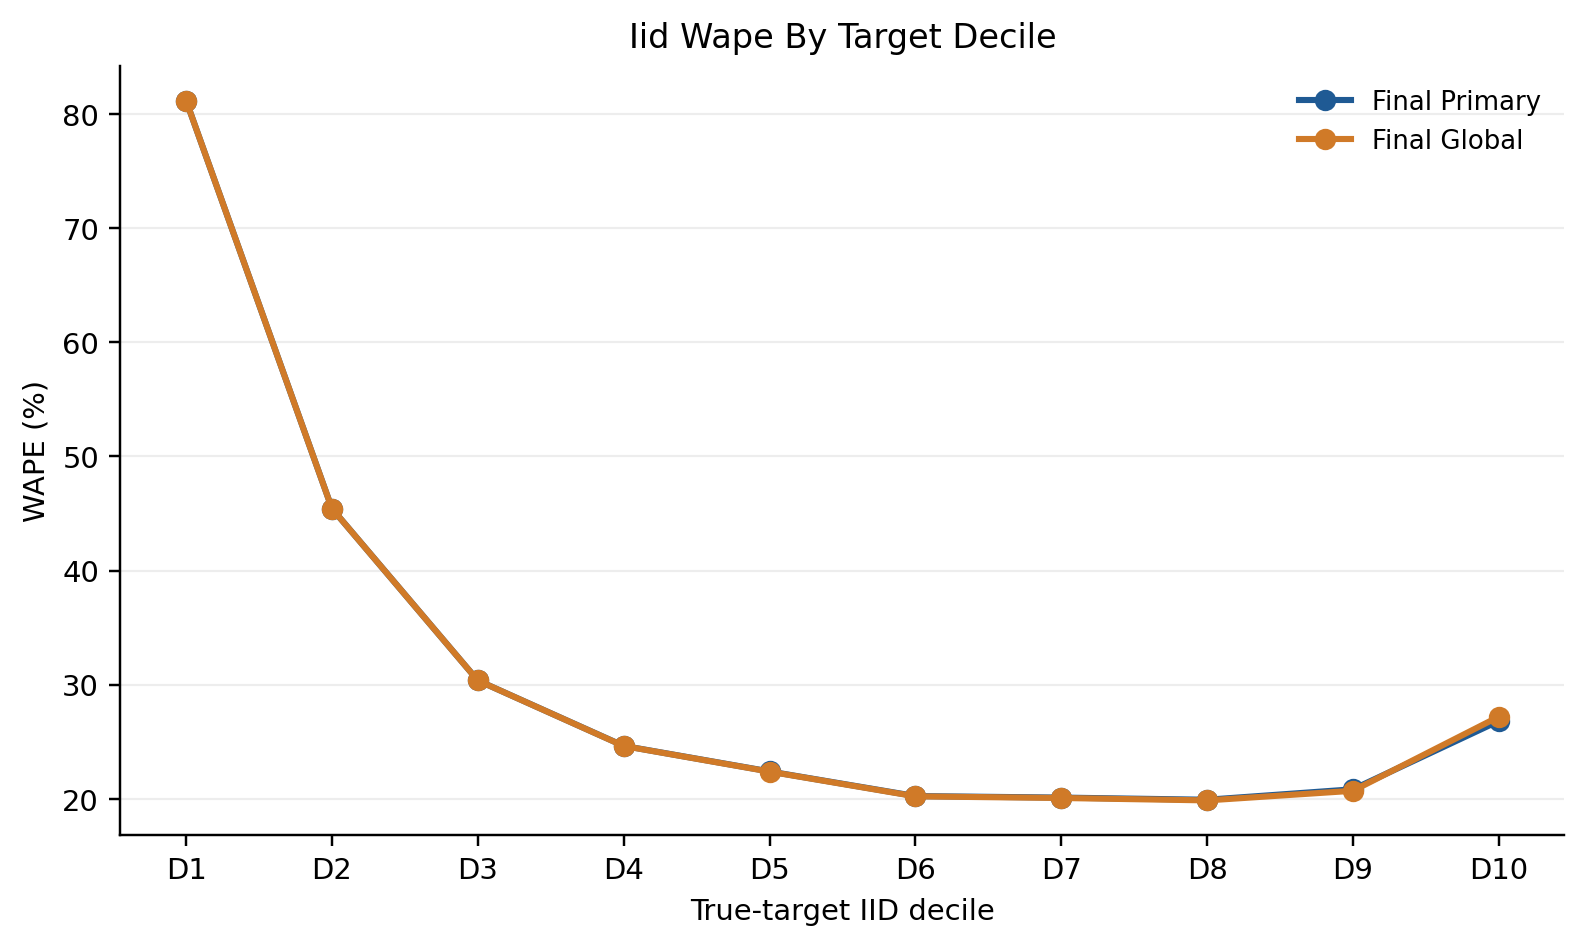

In [8]:
show_image('figure03_iid_mape_by_target_decile.png')
show_image('figure04_iid_wape_by_target_decile.png')

## 9. Decile Error

,Decile,n,Target min,Target max,Mean target,Primary MAE,Primary MAPE %,Primary WAPE %,Primary signed error,Primary underprediction rate,Global MAE,Global MAPE %,Global WAPE %,Primary minus Global MAE
0,D1,7719,1.0,70.0,36.073714,29.278094,104.078923,81.161850,24.053254,0.268299,29.278094,104.078923,81.161850,0.000000
1,D2,7366,71.0,110.0,92.147570,41.866583,46.359182,45.434278,33.253931,0.238800,41.862571,46.354492,45.429924,0.004012
2,D3,7664,111.0,142.0,126.832203,38.524686,30.507627,30.374531,24.464519,0.341467,38.521740,30.505341,30.372207,0.002947
3,D4,7338,143.0,171.0,156.838921,38.653750,24.739948,24.645509,17.918031,0.413737,38.639355,24.730409,24.636331,0.014395
4,D5,7495,172.0,202.0,186.958105,41.889122,22.375858,22.405620,11.443395,0.478719,41.861284,22.361631,22.390730,0.027838
5,D6,7464,203.0,239.0,220.540863,44.656468,20.279286,20.248614,2.150687,0.554528,44.605376,20.256087,20.225447,0.051092
6,D7,7456,240.0,282.0,260.035274,52.311609,20.127824,20.117120,-8.051781,0.615343,52.218694,20.092083,20.081389,0.092915
7,D8,7535,283.0,347.0,312.388587,62.252486,19.938875,19.927900,-18.848306,0.664234,62.072744,19.881396,19.870362,0.179742
8,D9,7482,348.0,438.0,391.989441,81.708484,20.817988,20.844562,-37.748759,0.726276,81.194312,20.690827,20.713393,0.514172
9,D10,7481,439.0,14400.0,716.854565,192.292490,24.281399,26.824477,-130.339177,0.776634,195.022229,24.252603,27.205271,-2.729739


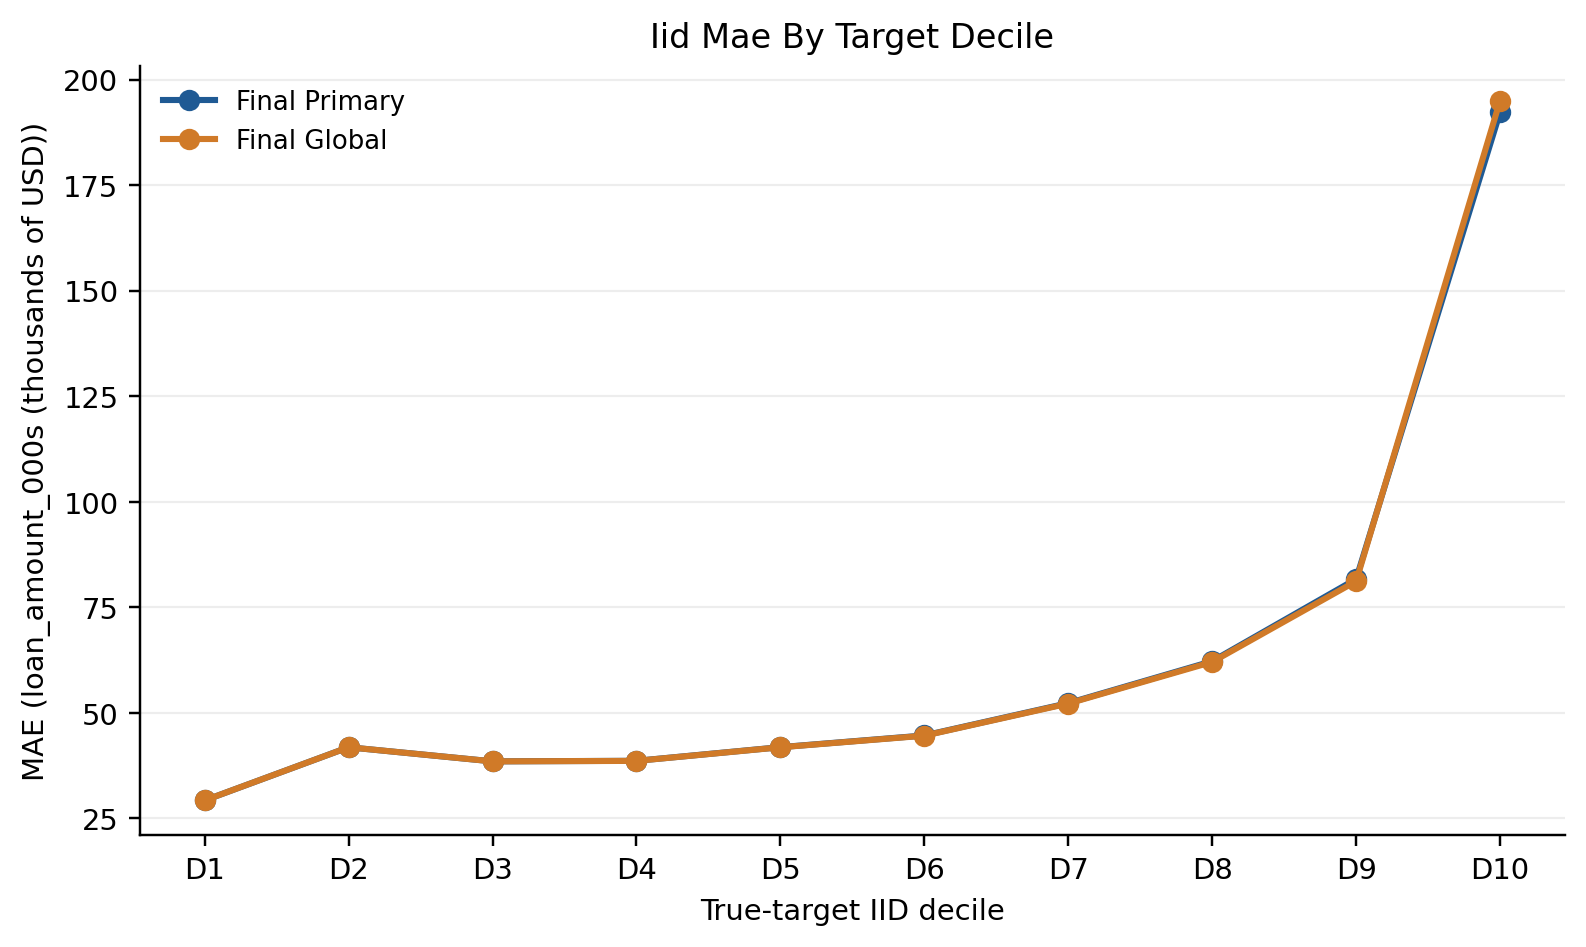

In [9]:
show_table('table_iid_decile_error_profile.csv')
show_image('figure02_iid_mae_by_target_decile.png')

## 10. Tail Analysis

Upper-Tail error improved relative to Global, but many high-loan observations remained underpredicted.

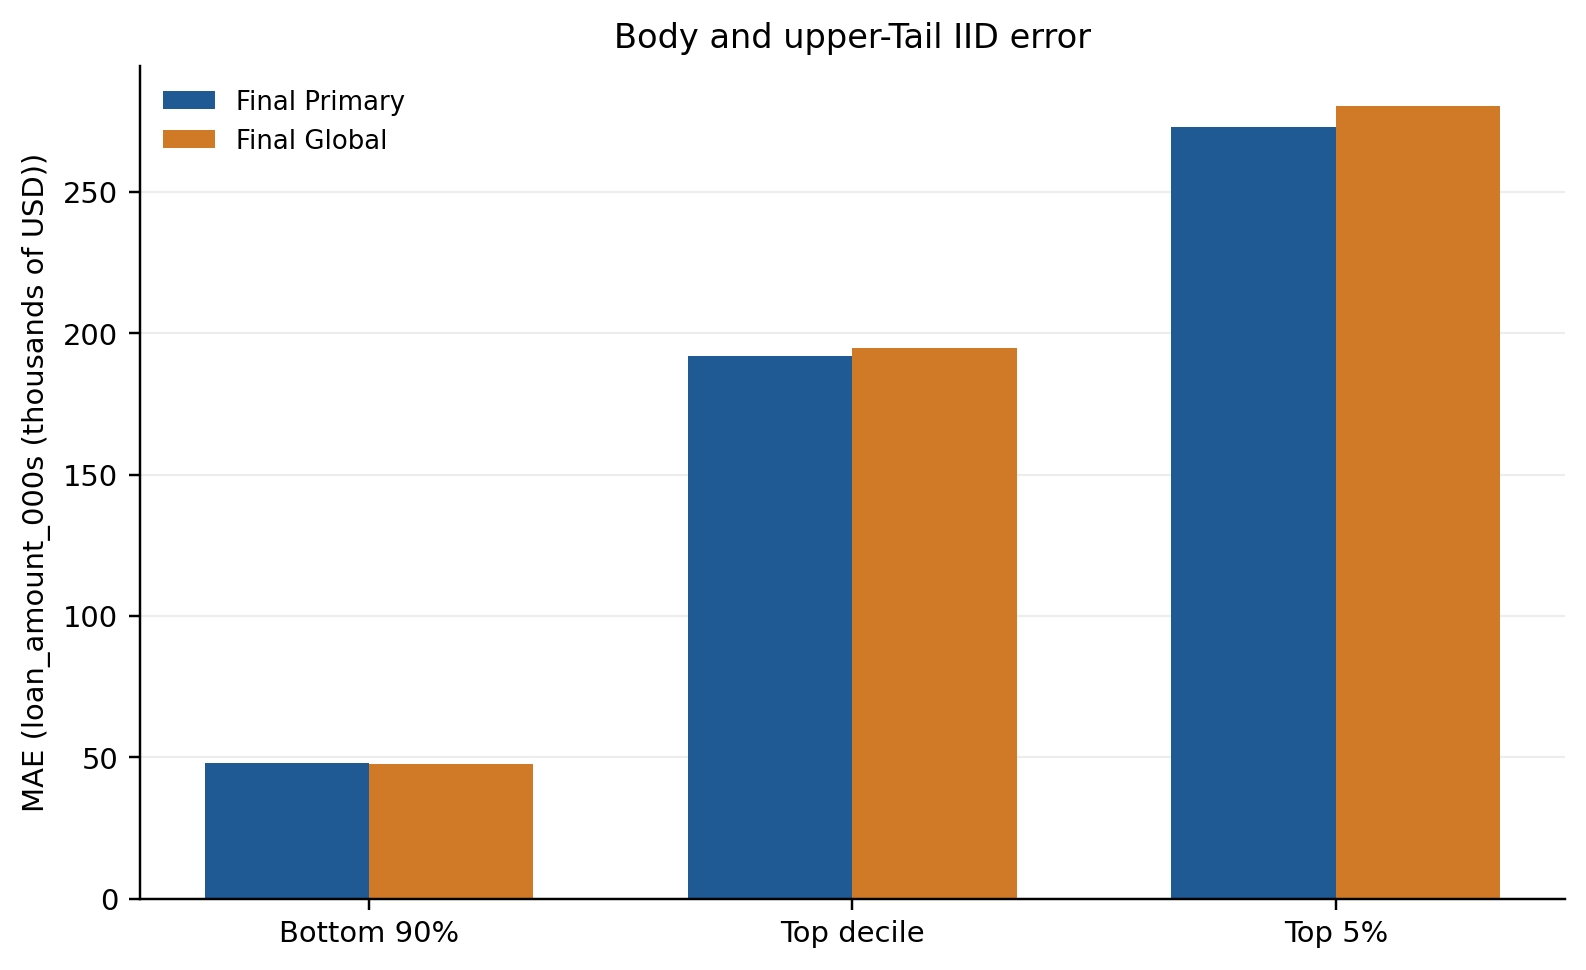

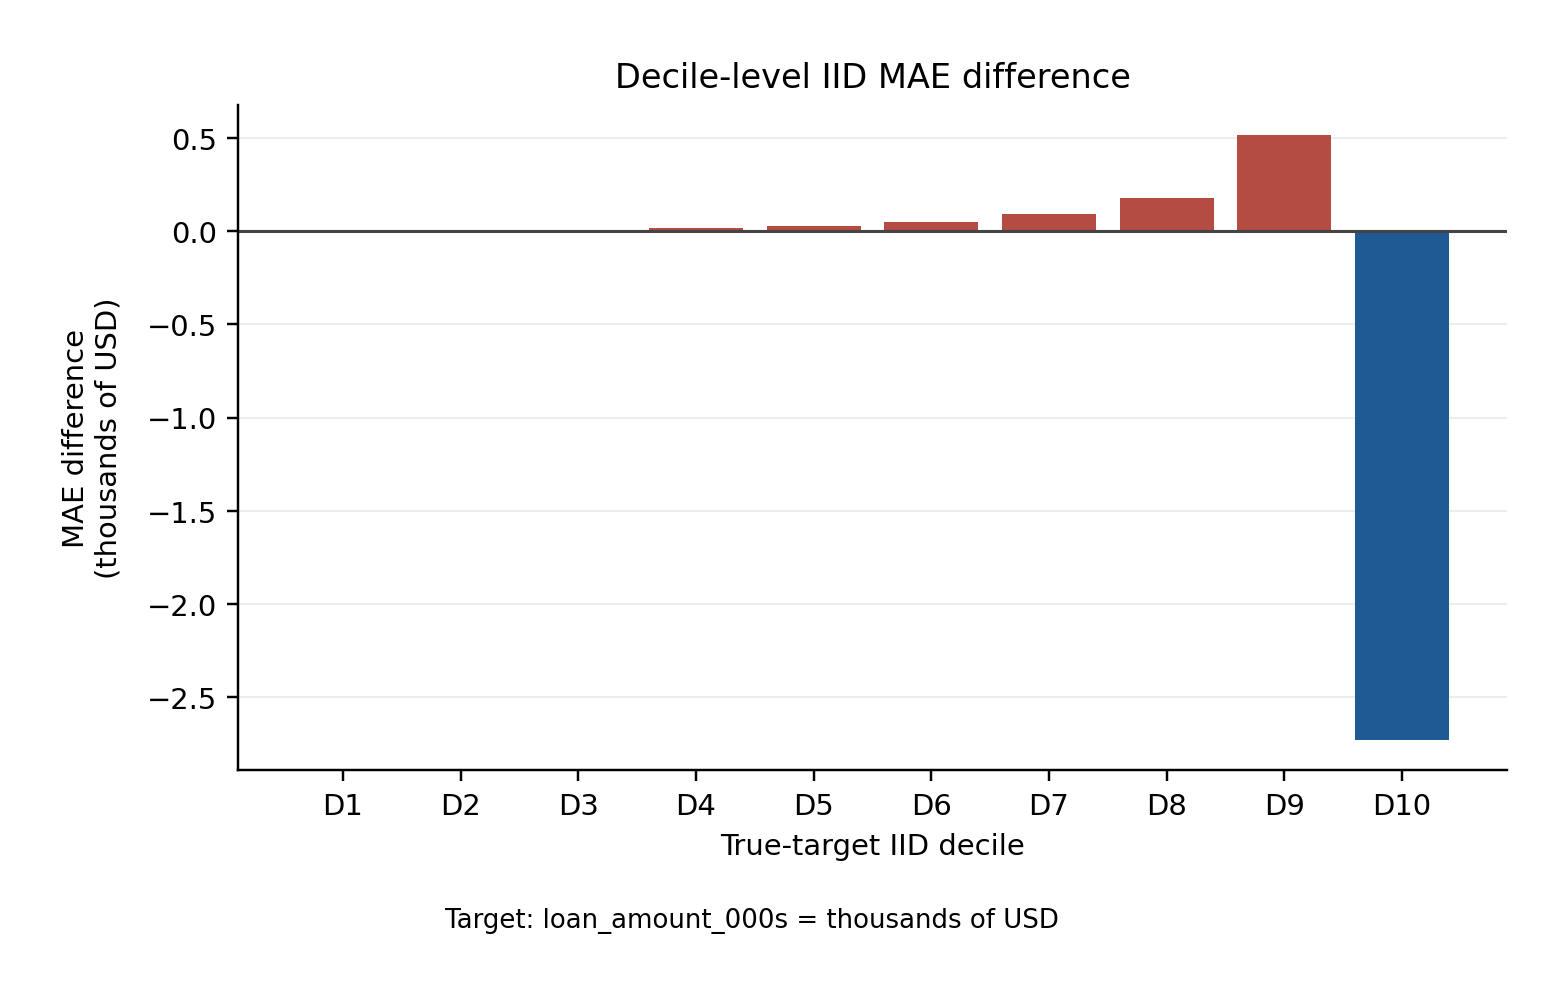

In [10]:
show_image('figure05_body_tail_error_comparison.png')
show_image('figure06_primary_minus_global_decile_mae.png')

## 11. Bootstrap Evidence

In [11]:
show_table('table_iid_primary_vs_global.csv')

,Metric,Observed Primary minus Global,Paired bootstrap mean difference,Paired bootstrap median difference,95% CI lower,95% CI upper,Fraction resamples favoring Primary,Resamples,Seed
0,MAE,-0.183723,-0.183492,-0.184574,-0.262989,-0.104811,1.0,500,42
1,RMSE,-2.477011,-2.454021,-2.432419,-3.514729,-1.542489,1.0,500,42
2,MAPE,0.030244,0.030365,0.030260,0.022524,0.038501,0.0,500,42
3,WAPE,-0.073623,-0.073511,-0.073983,-0.104840,-0.041947,1.0,500,42
4,Bottom-90 MAE,0.097799,0.098034,0.097687,0.081441,0.114905,0.0,500,42
5,Top-decile MAE,-2.716298,-2.715244,-2.720549,-3.472434,-1.939967,1.0,500,42
6,Top-5% MAE,-7.548490,-7.550688,-7.566098,-9.028809,-6.139156,1.0,500,42


## 12. Fairness Audit

The analysis describes predictive error differences. It does not assess lending decisions, causal discrimination, disparate treatment, or legal compliance. Target composition and small-group limits apply.

,Sensitive field,Eligible groups,Lowest MAE group,Highest MAE group,MAE gap,MAE ratio,Underprediction gap (pp),Largest Tail MAE gap,Tail scope,Tail lowest-MAE group,Tail highest-MAE group,Interpretation note
0,applicant_ethnicity_name,3,Hispanic or Latino,"Information not provided by applicant in mail,...",24.074484418463896,1.520343527775321,1.1153856377684956,62.11660703967087,IID_TOP5_TARGET,Hispanic or Latino,"Information not provided by applicant in mail,...",Descriptive predictive-error disparity; not a ...
1,co_applicant_ethnicity_name,4,No co-applicant,"Information not provided by applicant in mail,...",22.55567657096525,1.416293955955622,2.3617899987517568,63.167625611837394,IID_TOP5_TARGET,Hispanic or Latino,No co-applicant,Descriptive predictive-error disparity; not a ...
2,applicant_race_name_1,6,Black or African American,Asian,39.91804125380329,1.9203921147761085,11.018734379784853,85.32864379115261,IID_TOP5_TARGET,Asian,White,Descriptive predictive-error disparity; not a ...
3,co_applicant_race_name_1,5,Black or African American,Asian,43.25496404918562,1.804564697959376,5.012845762357126,66.17242141070687,IID_TOP5_TARGET,Asian,White,Descriptive predictive-error disparity; not a ...
4,applicant_sex_name,3,Female,"Information not provided by applicant in mail,...",21.151148779218296,1.4105014930001007,3.8601291241572246,70.91014970311832,IID_TOP5_TARGET,Female,"Information not provided by applicant in mail,...",Descriptive predictive-error disparity; not a ...
5,co_applicant_sex_name,4,No co-applicant,"Information not provided by applicant in mail,...",25.15937547576812,1.4643485604711417,5.762236621203831,44.52124762974489,IID_TOP5_TARGET,Male,"Information not provided by applicant in mail,...",Descriptive predictive-error disparity; not a ...
6,majority_minority_tract,2,Majority minority,Not majority minority,8.20592818824558,1.1468277702281375,0.474250365518758,73.11952421741645,IID_TOP5_TARGET,Majority minority,Not majority minority,Descriptive predictive-error disparity; not a ...
7,minority_population,0,NOT_AVAILABLE_FROM_FROZEN_EVIDENCE,NOT_AVAILABLE_FROM_FROZEN_EVIDENCE,NOT_AVAILABLE_FROM_FROZEN_EVIDENCE,NOT_AVAILABLE_FROM_FROZEN_EVIDENCE,NOT_AVAILABLE_FROM_FROZEN_EVIDENCE,NOT_AVAILABLE_FROM_FROZEN_EVIDENCE,NOT_AVAILABLE_FROM_FROZEN_EVIDENCE,NOT_AVAILABLE_FROM_FROZEN_EVIDENCE,NOT_AVAILABLE_FROM_FROZEN_EVIDENCE,No eligible ranked levels under the frozen n t...


,Intersection,Largest eligible MAE gap,Lowest MAE group,Lowest group n,Lowest group MAE,Highest MAE group,Highest group n,Highest group MAE,Uncertainty
0,applicant_race_x_applicant_sex,49.170054,Black or African American | Female,2110,38.746901,Asian | Male,3334,87.916955,NOT_AVAILABLE_FROM_FROZEN_EVIDENCE
1,applicant_ethnicity_x_applicant_sex,30.953173,Hispanic or Latino | Female,2392,42.540774,"Information not provided by applicant in mail,...",4715,73.493947,NOT_AVAILABLE_FROM_FROZEN_EVIDENCE


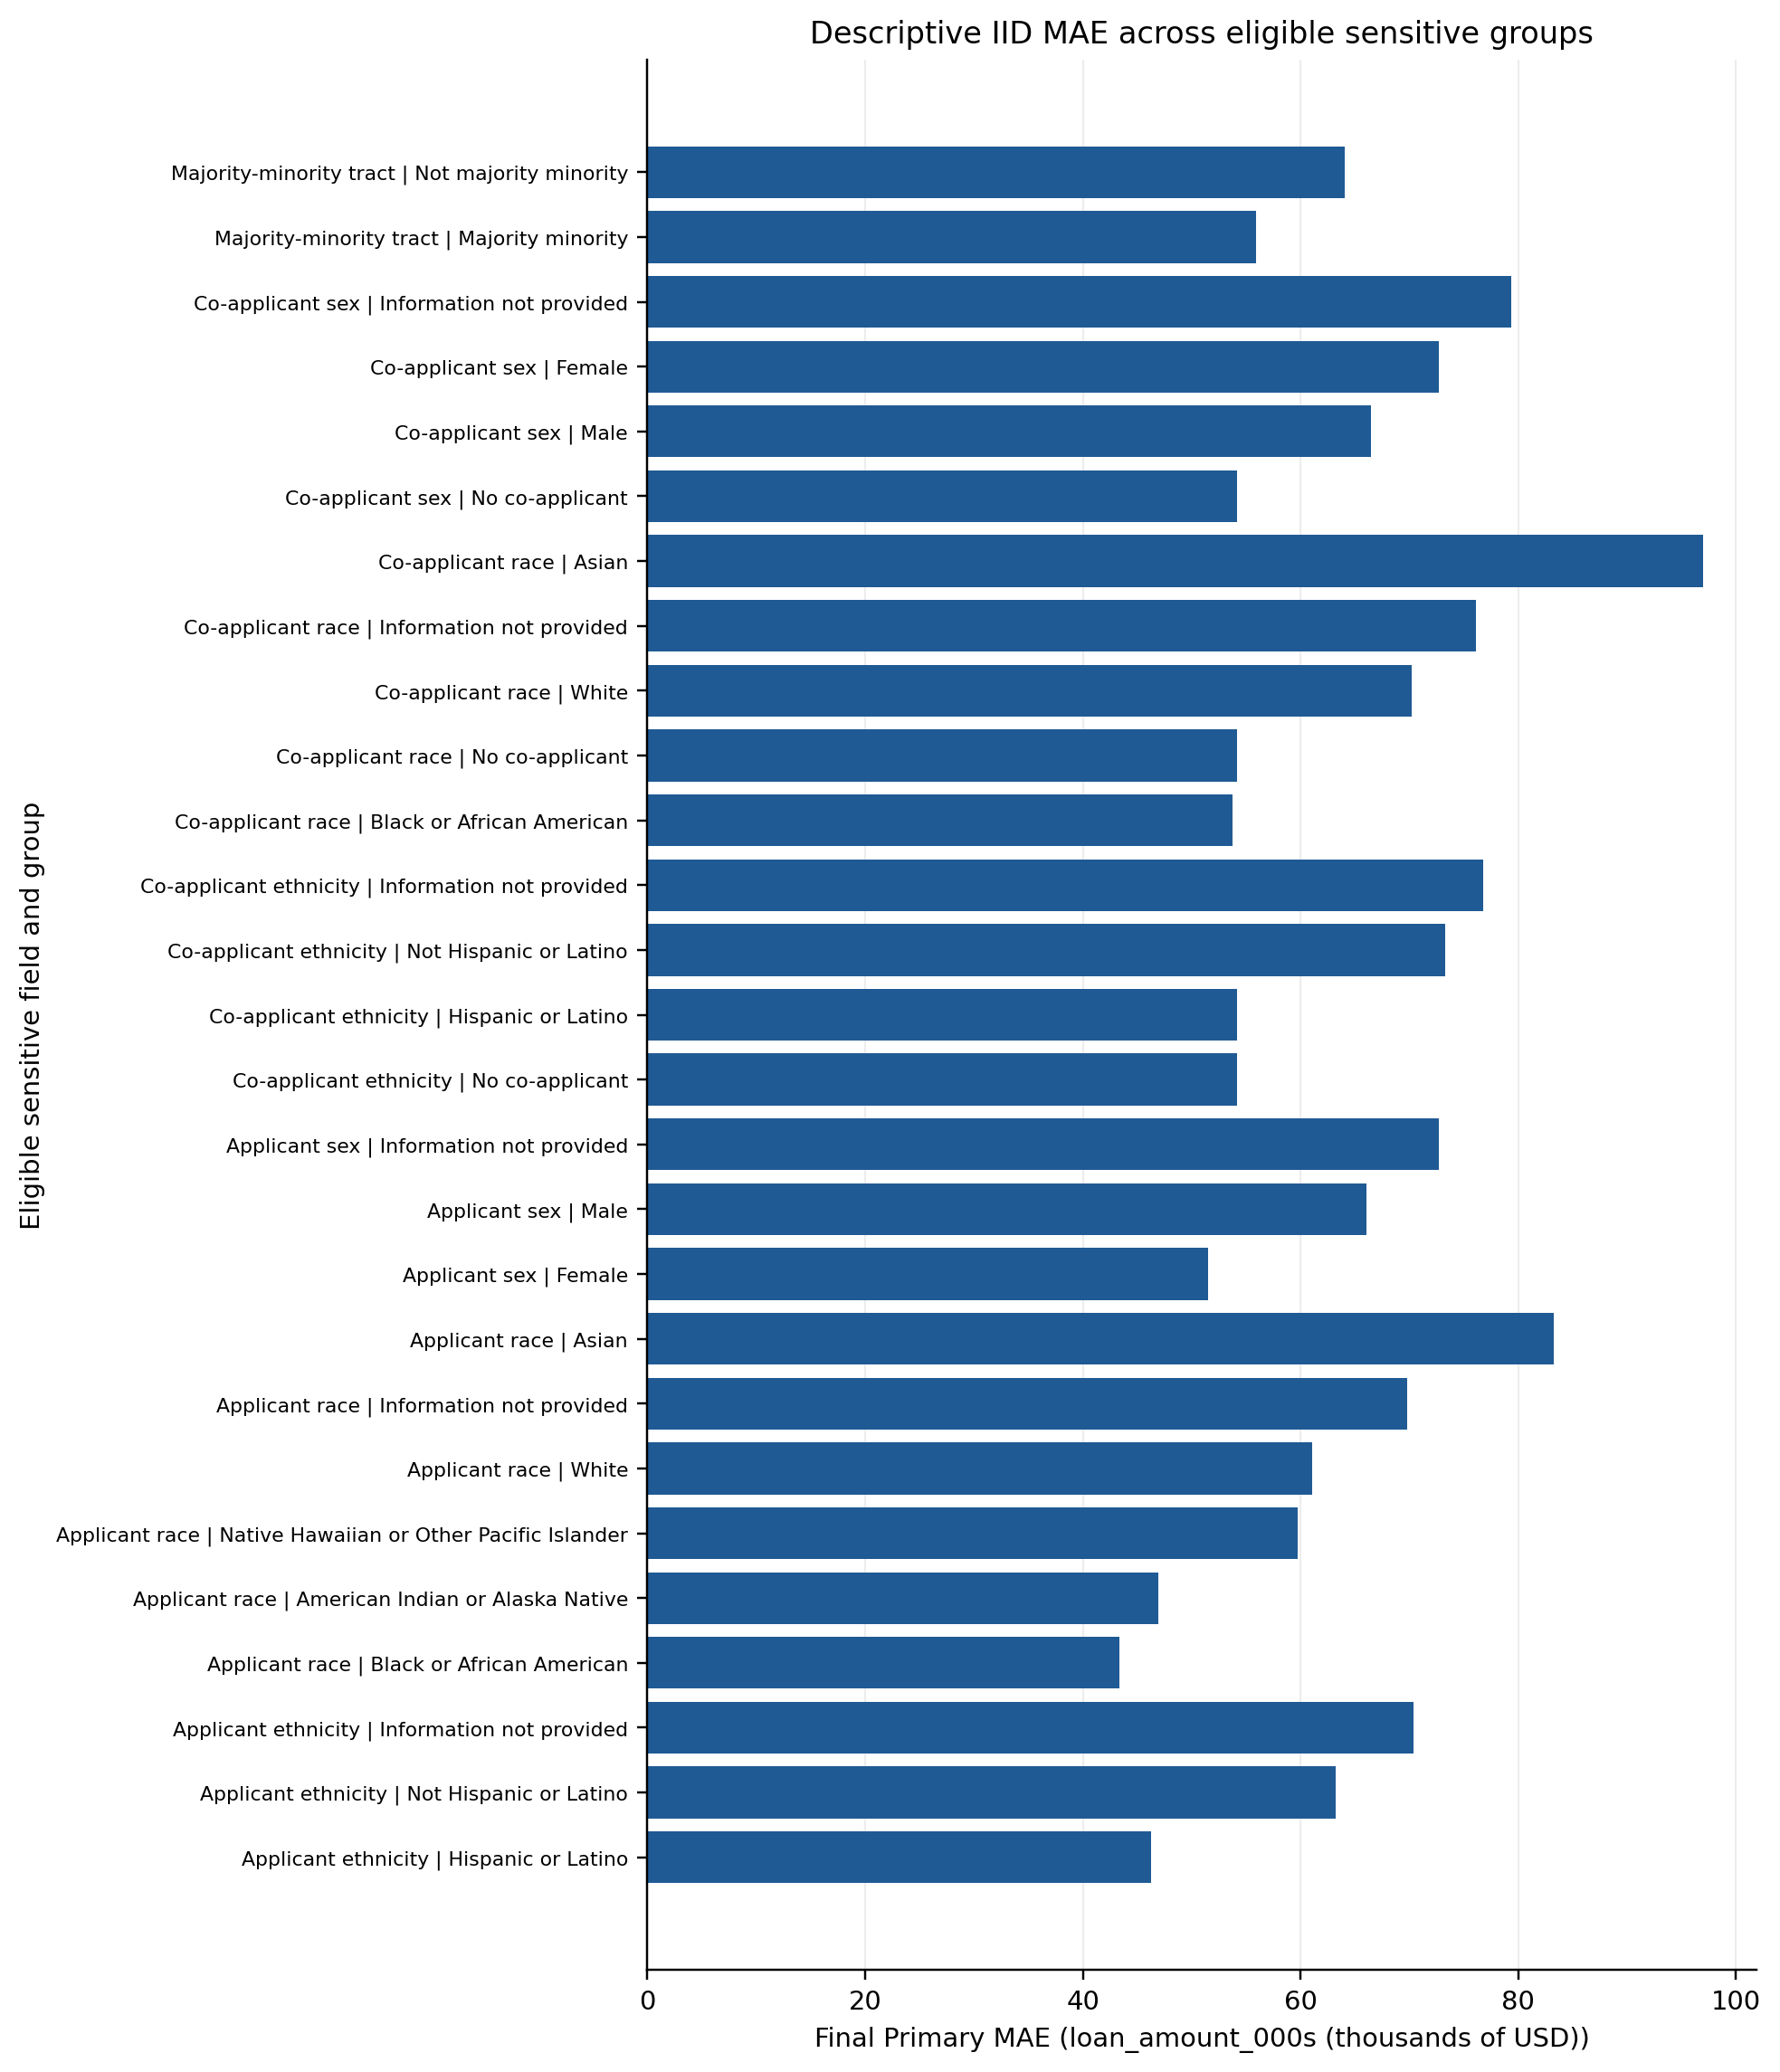

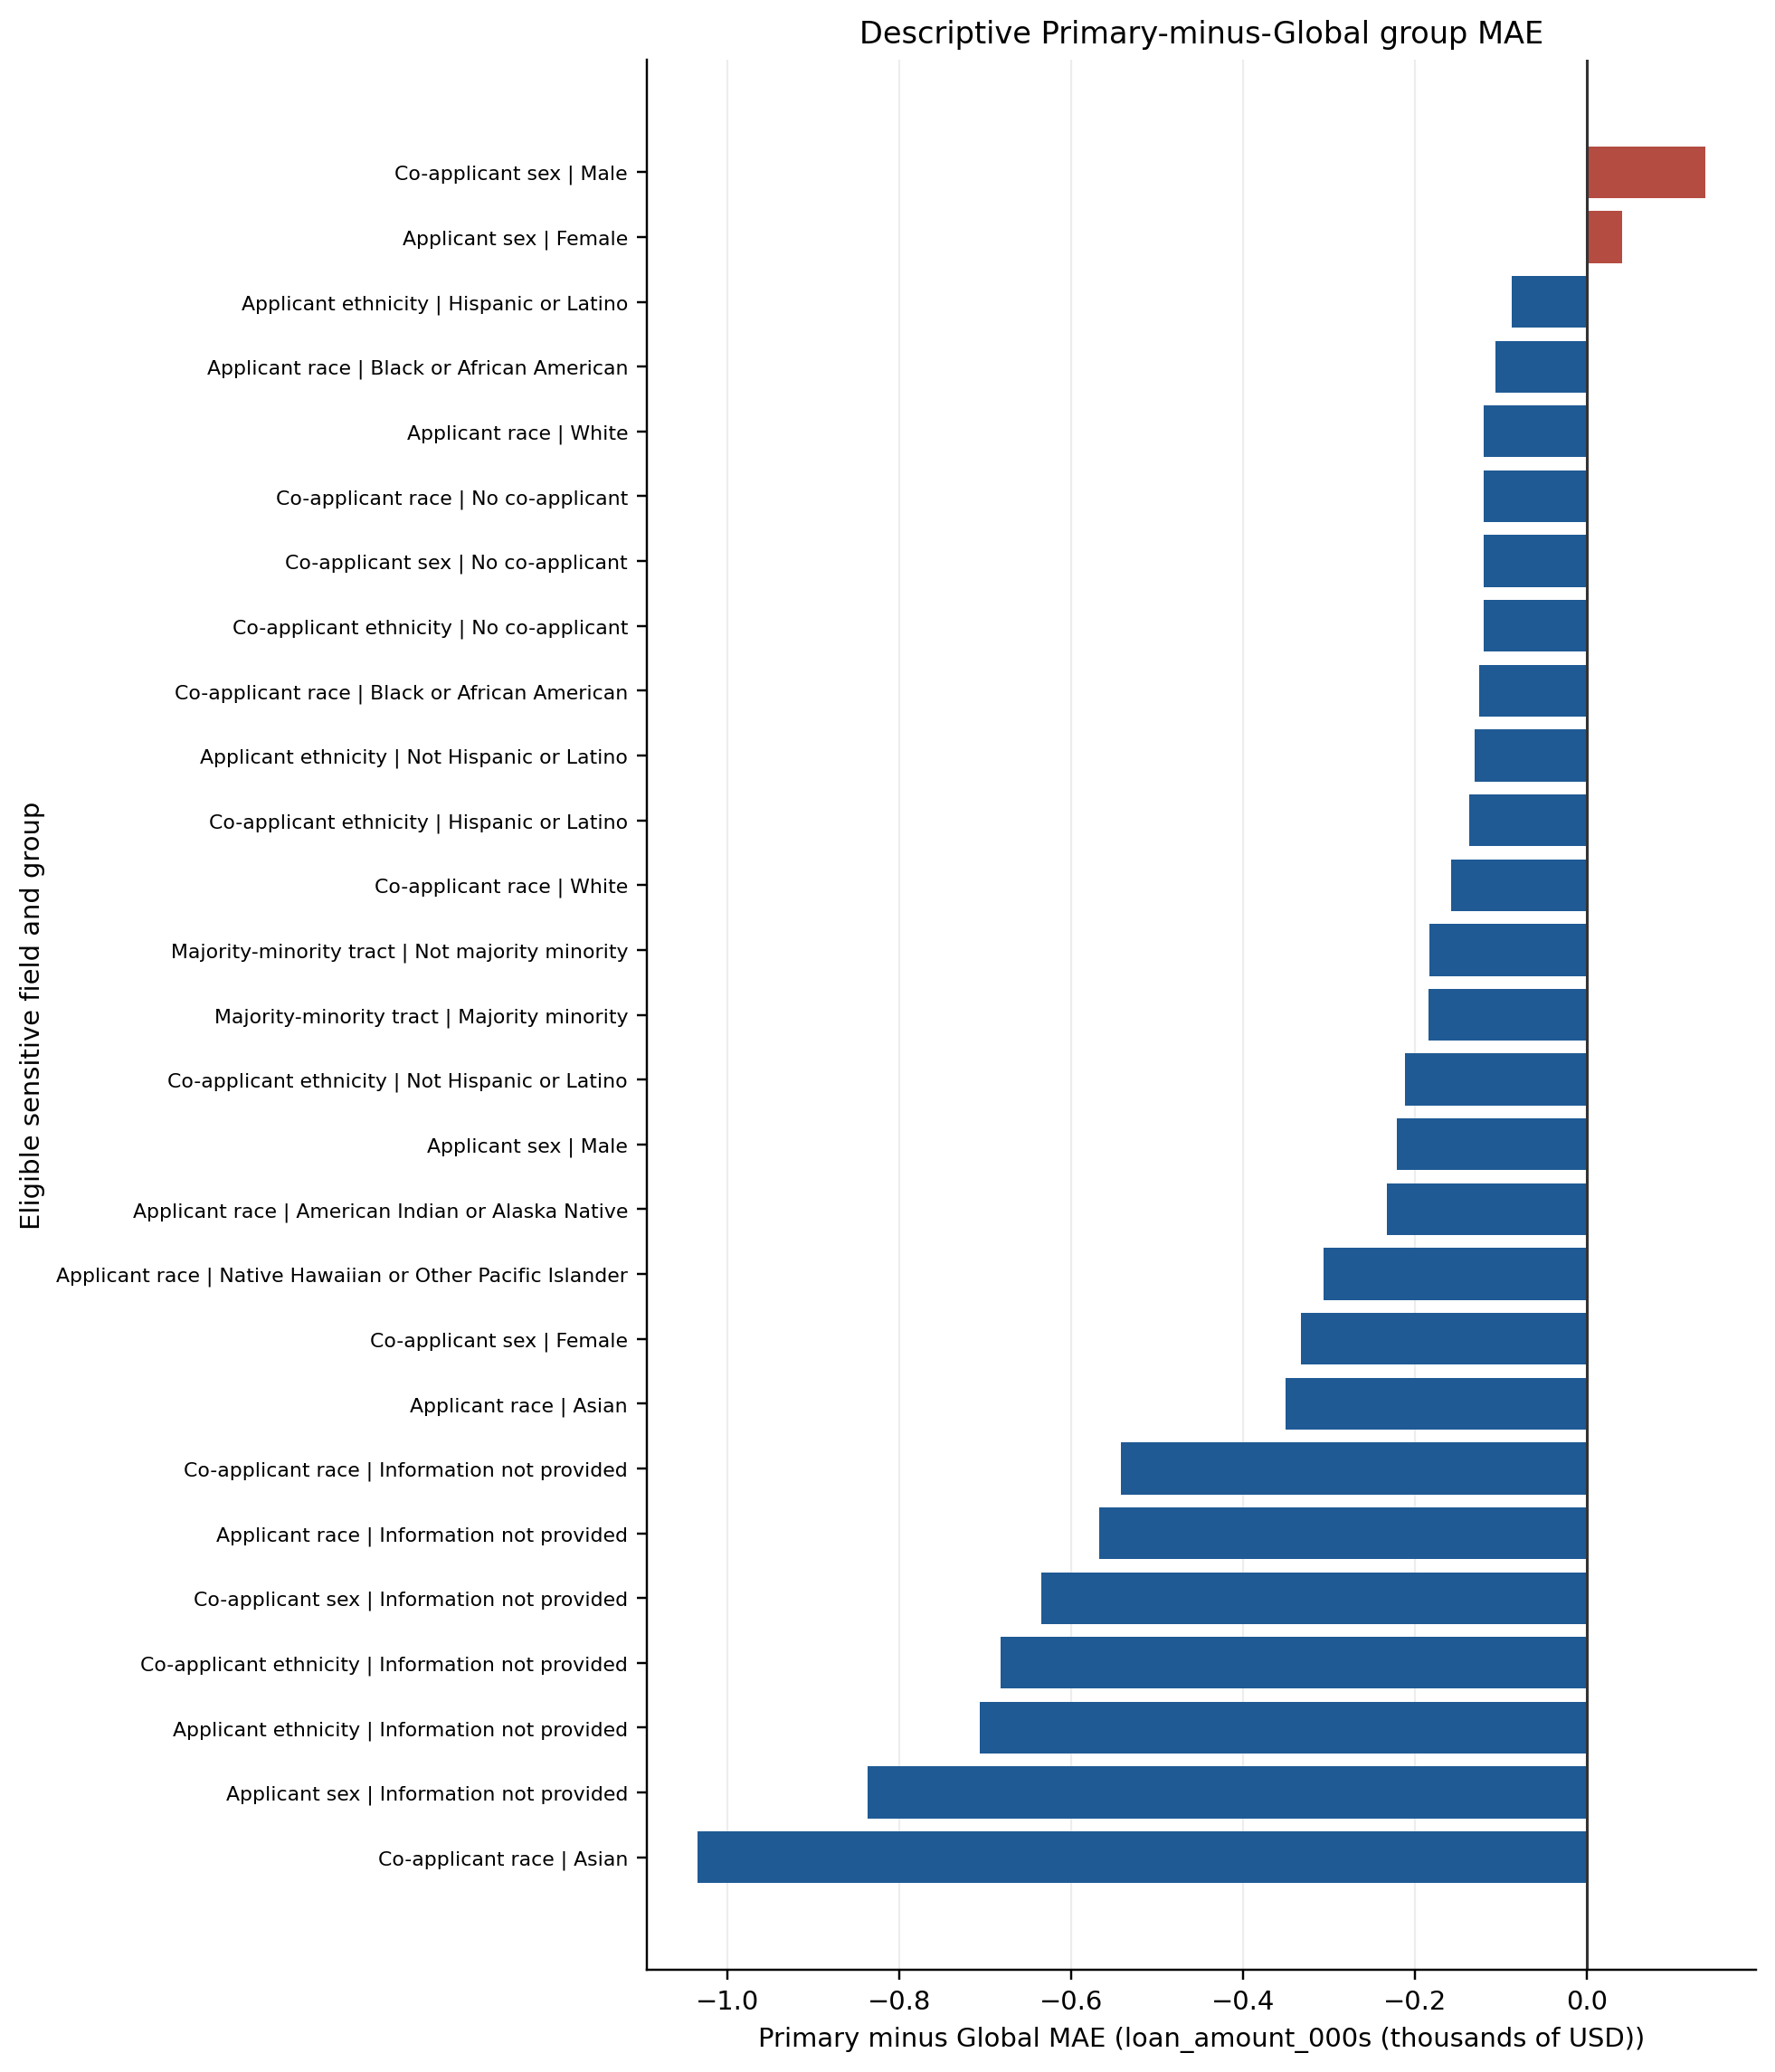

In [12]:
show_table('table_fairness_disparities.csv')
show_table('table_intersectional_fairness.csv')
show_image('figure08_fairness_mae_eligible_groups.png')
show_image('figure09_primary_minus_global_fairness_mae.png')

## 13. Explainability

Global prediction, routing, and residual correction use separate explanation spaces. Feature attribution is not causal, and raw SHAP magnitudes are not merged across incompatible components.

,Component,Rank,Feature,Importance / rank score,Explanation space,Interpretation role
0,Global consensus,1,applicant_income_000s,0.982353,rank consensus across separate native componen...,Global loan-amount prediction driver
1,Global consensus,2,lien_status_name,0.917647,rank consensus across separate native componen...,Global loan-amount prediction driver
2,Global consensus,3,loan_purpose_name,0.870588,rank consensus across separate native componen...,Global loan-amount prediction driver
3,Global consensus,4,msamd_name,0.864706,rank consensus across separate native componen...,Global loan-amount prediction driver
4,Global consensus,5,owner_occupancy_name,0.835294,rank consensus across separate native componen...,Global loan-amount prediction driver
5,Global consensus,6,tract_to_msamd_income,0.794118,rank consensus across separate native componen...,Global loan-amount prediction driver
6,Global consensus,7,loan_type_name,0.741176,rank consensus across separate native componen...,Global loan-amount prediction driver
7,Global consensus,8,hud_median_family_income,0.735294,rank consensus across separate native componen...,Global loan-amount prediction driver
8,Global consensus,9,us_region,0.729412,rank consensus across separate native componen...,Global loan-amount prediction driver
9,Global consensus,10,county_name,0.694118,rank consensus across separate native componen...,Global loan-amount prediction driver


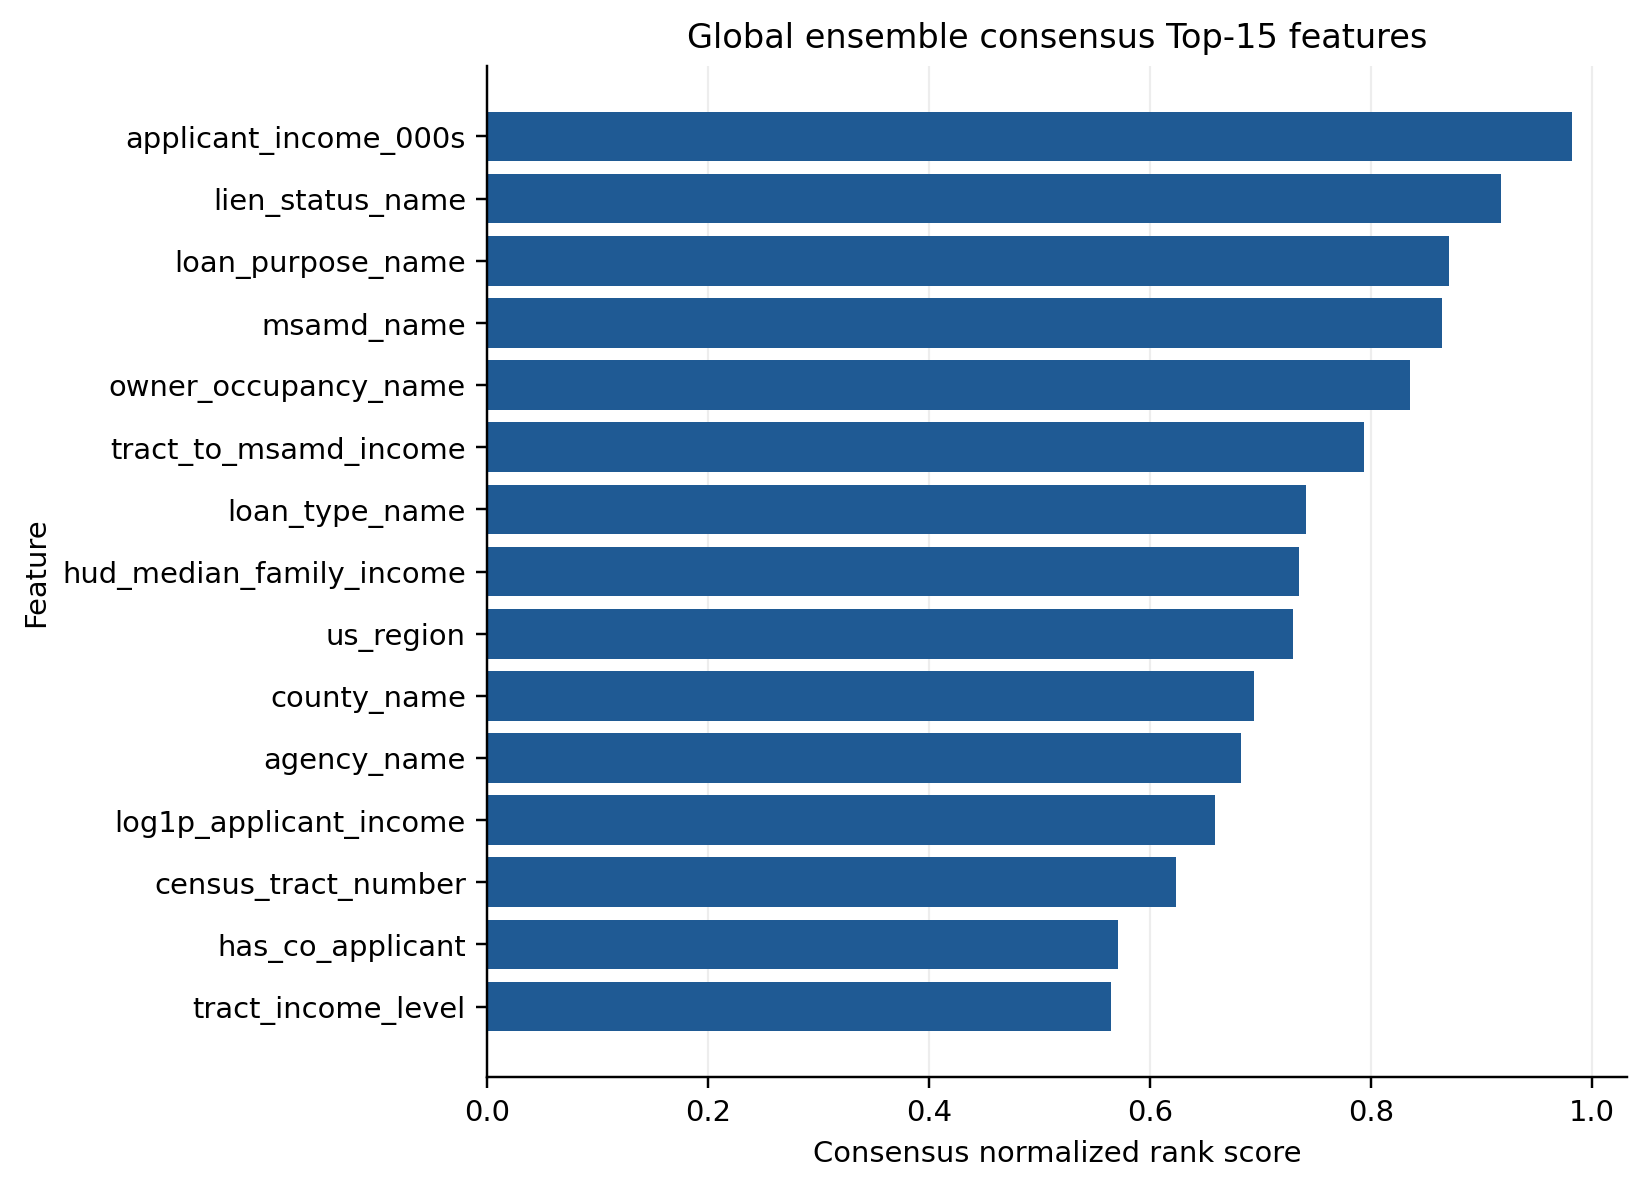

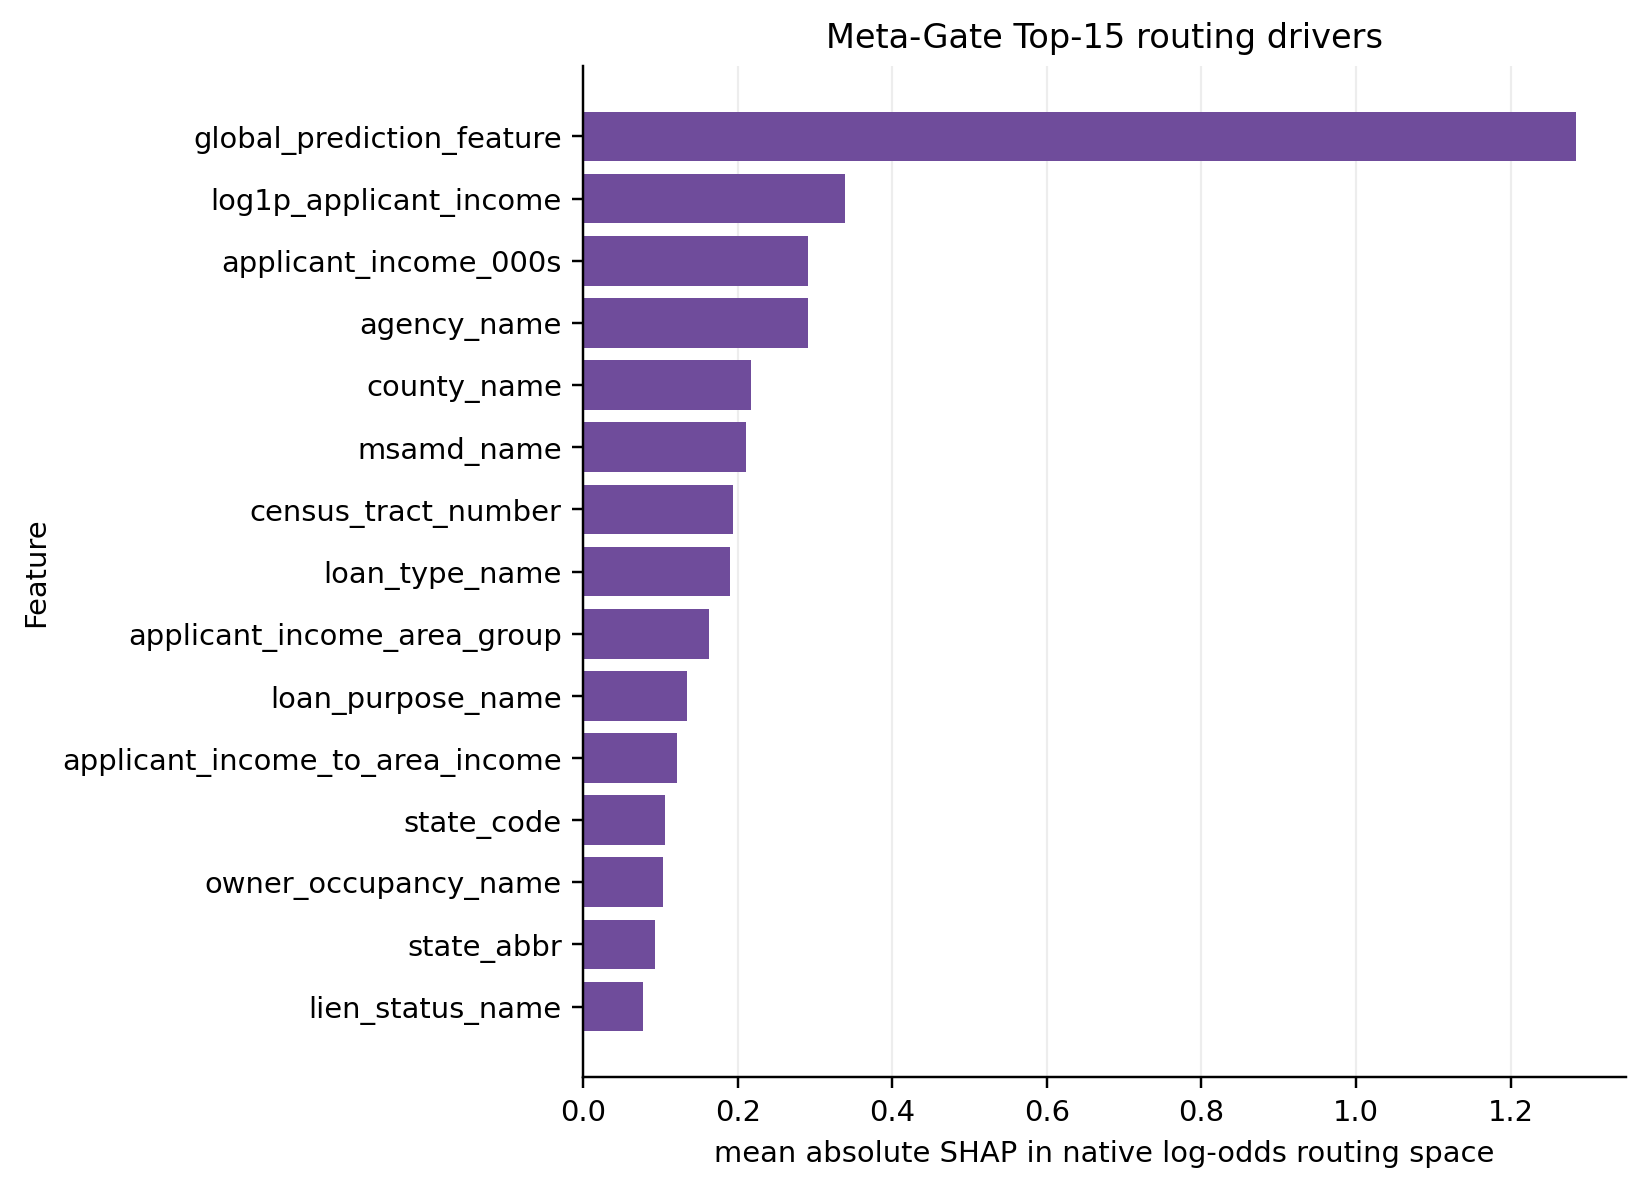

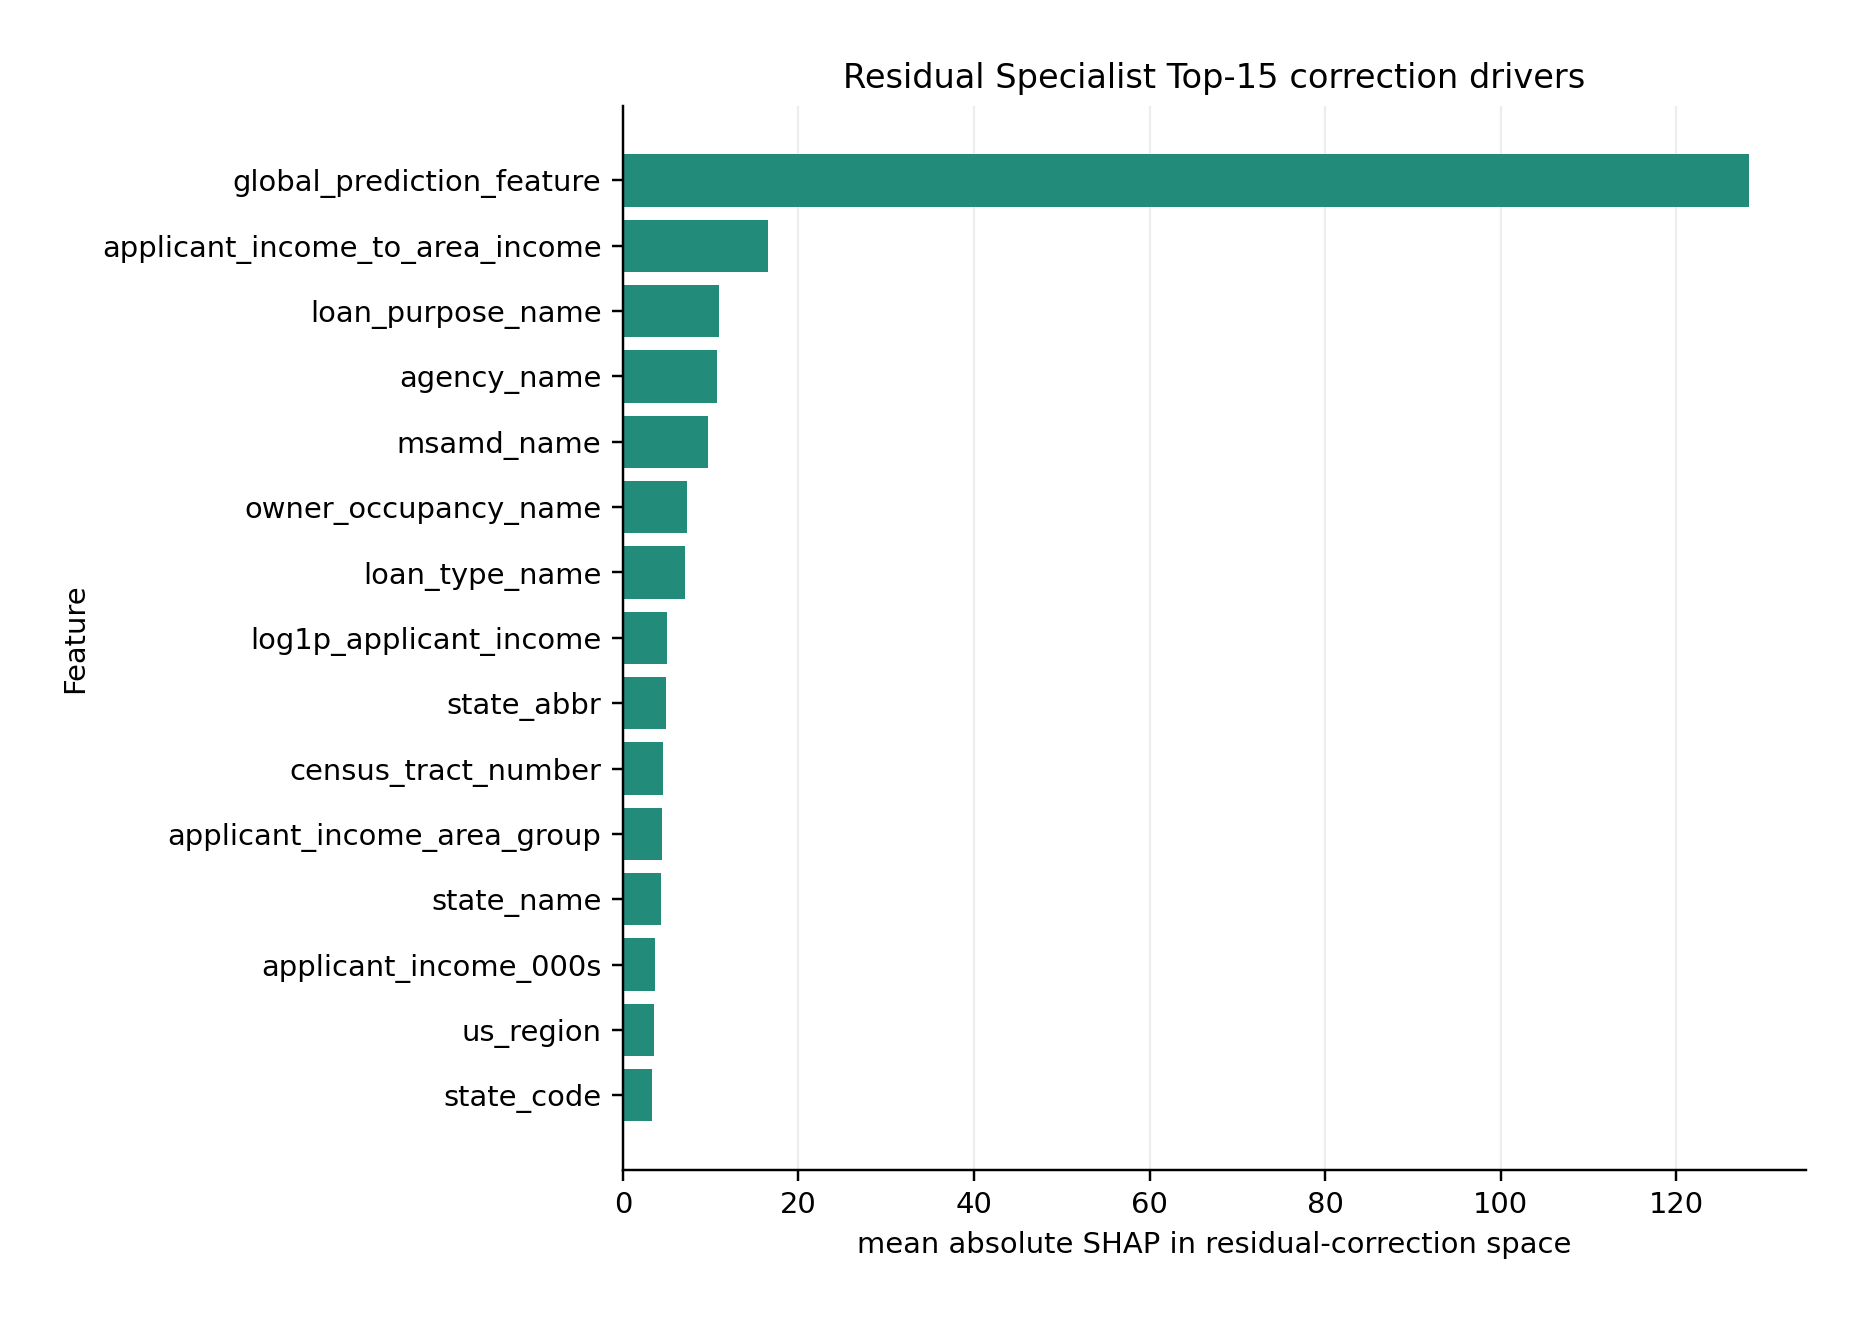

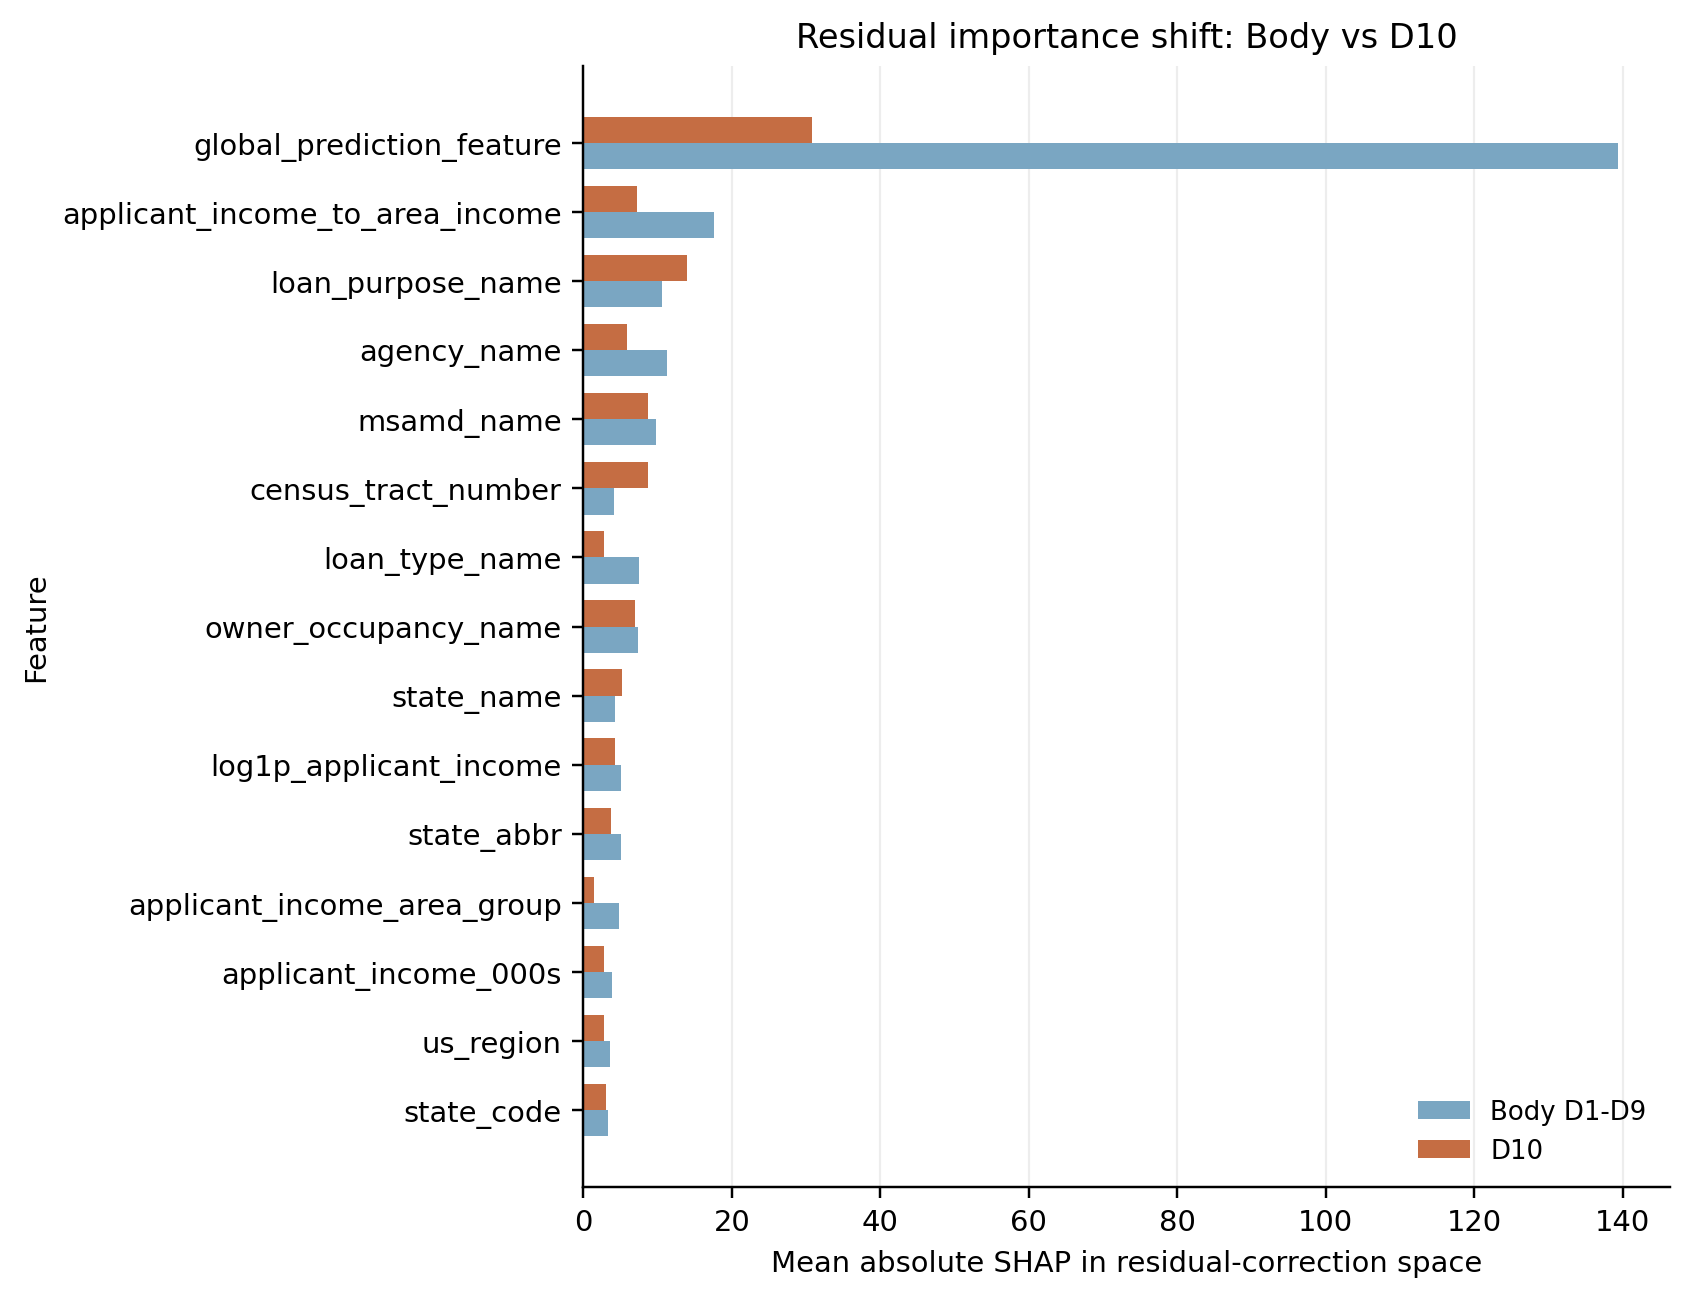

In [13]:
show_table('table_final_explainability.csv')
show_image('figure10_global_consensus_top15.png')
show_image('figure11_meta_gate_top15.png')
show_image('figure12_residual_specialist_top15.png')
show_image('figure13_residual_body_vs_d10_importance.png')

## 14. Routing Mechanism

,Measure,Value,Frozen source
0,IID rows,75000.000000,outputs/reports/prompt5a_routing_diagnostics.csv
1,Routed rows,3583.000000,outputs/reports/prompt5a_routing_diagnostics.csv
2,Routing rate,0.047773,outputs/reports/prompt5a_routing_diagnostics.csv
3,Mean routed correction,27.773618,Frozen aggregate ratio from prompt5a_routing_d...
4,Median absolute routed correction,16.551000,Prompt 5C authorization Section 7; frozen Prom...
5,Positive correction rate,0.043693,outputs/reports/prompt5b_correction_behavior.csv
6,Negative correction rate,0.004080,outputs/reports/prompt5b_correction_behavior.csv
7,Zero correction rate,0.952227,outputs/reports/prompt5b_correction_behavior.csv
8,Routed-row realized benefit,3.845729,outputs/reports/prompt5a_routing_diagnostics.csv


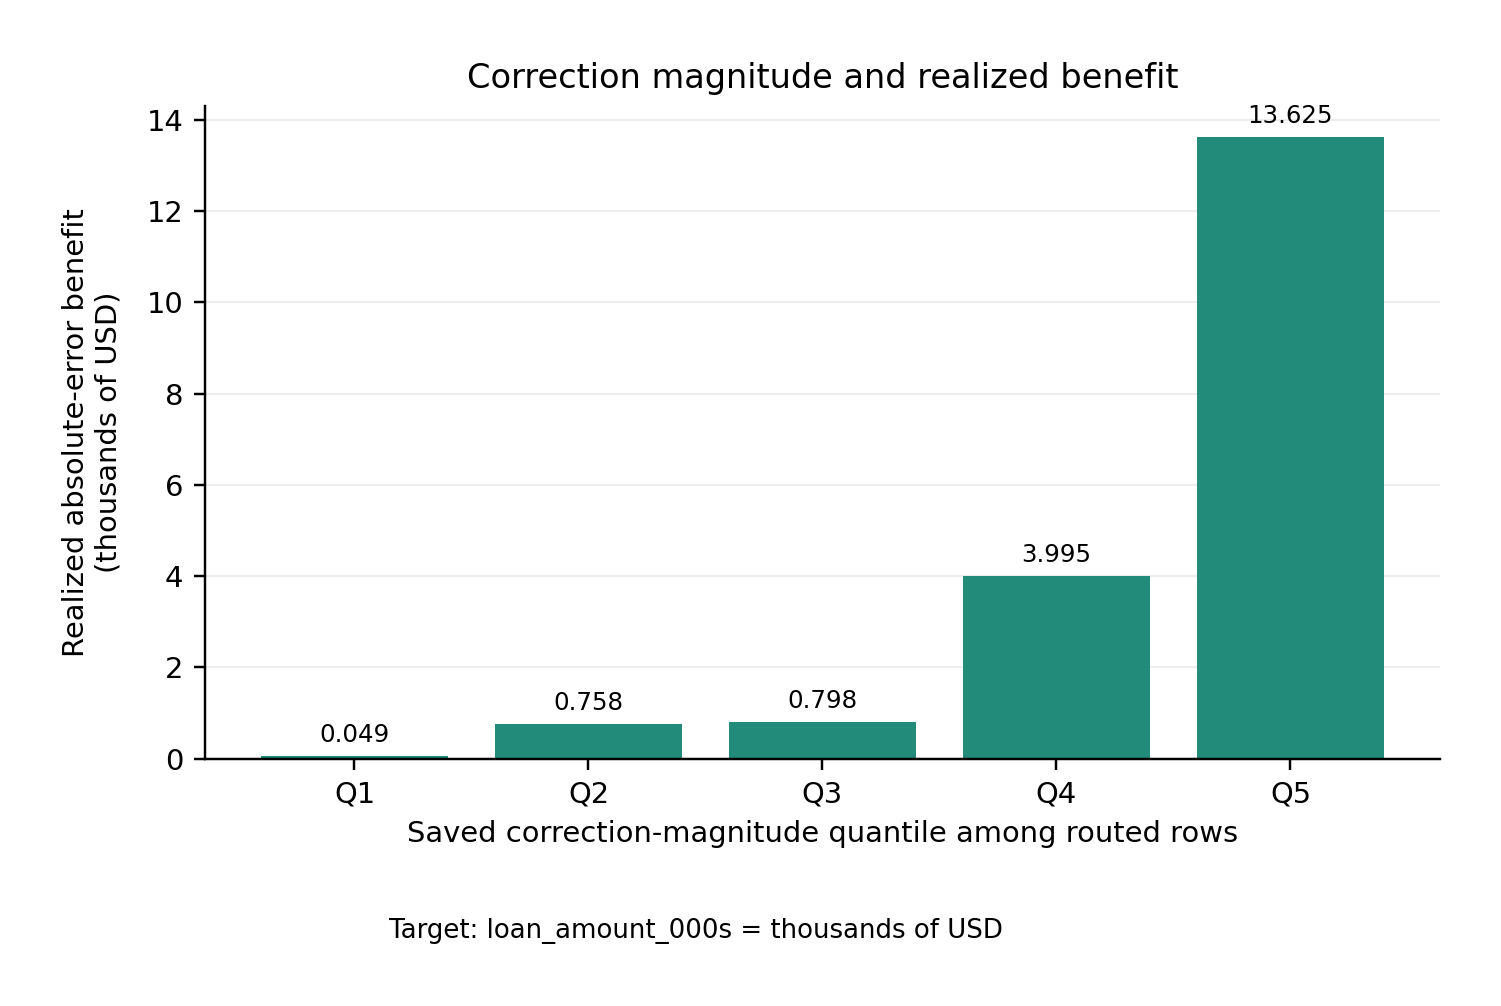

In [14]:
show_table('table_stage3_mechanism.csv')
show_image('figure14_correction_magnitude_realized_benefit.png')

## 15. Limitations

HMDA 2017 lacks direct property-value and LTV-like variables. Tail underprediction remains. C2 failed. Development was adaptive, IID covered only two predeclared models, fairness results are descriptive, and explanation is not causal.

In [15]:
display(Markdown((FINAL / 'PAPER_LIMITATIONS_TEXT.md').read_text(encoding='utf-8')))

# Paper-Ready Limitations Text

The project used HMDA 2017 information, which does not capture every determinant of loan amount. In particular, the feature set lacked direct property-value and LTV-like measures. These missing variables limit the model's ability to represent collateral value and financing structure.

The upper Tail remained the principal predictive limitation. Even after final selection and IID validation, the model underpredicted many high-loan observations. The frozen Stage 3 Primary improved observed Top-decile and Top-5% errors relative to the Global comparator, but it did not meet frozen C2, which required at least a 3% Top-decile MAE improvement.

Development research was adaptive and tested many modeling and routing choices. Development scores must therefore not be described as independent Test evidence. The one-time IID evaluation was limited to two models that were declared before the holdout was opened. It does not support claims about the IID ranking of every model trained during Development.

Sensitive variables were excluded from predictive inputs, but exclusion alone does not establish fairness. The post-prediction audit found descriptive error differences across available groups. The fairness analysis evaluates predictive error disparities across available sensitive-group labels. It does not assess lending approval decisions, causal discrimination, disparate treatment, or legal compliance. Small-group uncertainty, multiple descriptive comparisons, and differing target composition limit interpretation.

SHAP and rank-based feature attributions describe fitted-model behavior. SHAP is not causal evidence, and no causal interpretation is made. XGBoost attributions are in native log1p space, and attribution magnitudes from incompatible models were not merged into a single Stage 3 decomposition.

Geographic and tract-context variables may proxy unobserved socioeconomic or market context. Their presence supports prediction but requires careful monitoring and governance. The final system optimizes loan-amount prediction; it does not optimize or evaluate lending decisions, approval equity, or legal compliance.

A new population, new time period, or changed data contract requires fresh validation. Because the original IID holdout has already been consumed, another independent final evaluation would require a new holdout.


---

Frozen audit provenance: Primary bundle SHA-256 5349ab15fd1c8182ef539f435cc4f065e71ee7da047de09a4dc271c9097e0c08; Global bundle SHA-256 6f61a0be1fc90d2331b08dada63a453f6c5410d5783f46f1e0cbcbf425f75597; final pre-IID freeze SHA-256 8f2b8e4fda80056770b916b7859ad0f6f89f2948236320e6815e082fadca35c1; final fairness and explainability SHA-256 2025ec95cc564238e72fbb82ac33670c0272f166cf93d46dc1aa7a59f1b890df.


## 16. Reproducibility

The final package preserves hashes for evidence, models, documents, tables, figures, and this notebook. Original IID files remain closed.

In [16]:
show_table('table_global_component_importance.csv', rows=15)

,Component,Rank,Feature,Mean absolute SHAP,Attribution space,Native-space note
0,CatBoost,1,log1p_applicant_income,29.898459,raw loan amount (thousand USD),Raw loan-amount space (thousands of USD).
1,CatBoost,2,applicant_income_000s,25.678638,raw loan amount (thousand USD),Raw loan-amount space (thousands of USD).
2,CatBoost,3,msamd_name,25.629440,raw loan amount (thousand USD),Raw loan-amount space (thousands of USD).
3,CatBoost,4,lien_status_name,18.699700,raw loan amount (thousand USD),Raw loan-amount space (thousands of USD).
4,CatBoost,5,loan_purpose_name,15.603564,raw loan amount (thousand USD),Raw loan-amount space (thousands of USD).
5,CatBoost,6,owner_occupancy_name,11.030987,raw loan amount (thousand USD),Raw loan-amount space (thousands of USD).
6,CatBoost,7,tract_income_ratio,9.129890,raw loan amount (thousand USD),Raw loan-amount space (thousands of USD).
7,CatBoost,8,county_name,8.699005,raw loan amount (thousand USD),Raw loan-amount space (thousands of USD).
8,CatBoost,9,tract_income_level,8.075720,raw loan amount (thousand USD),Raw loan-amount space (thousands of USD).
9,CatBoost,10,loan_type_name,6.866924,raw loan amount (thousand USD),Raw loan-amount space (thousands of USD).


## 17. Final Conclusions

The frozen Primary is a reproducible balanced compromise. It improved observed overall IID MAE and several Tail measures relative to Global, passed 5/6 frozen conditions, and did not meet C2. No further modeling or IID analysis is authorized.